## Q1 – Supervised Learning: Heart Disease Classification
**Dataset:** `q1_heart_disease.csv`  
**Target column:** `heart_disease` (1 = disease present, 0 = absent)

### Task 1 – Data Loading and Inspection

**Goal:** Load the dataset and understand its basic structure. To check:
- **Shape** – how many rows and columns the dataset has
- **Data types** – whether each column is numeric or categorical
- **Missing values** – columns that will need imputation later
- **First five rows** – a quick visual sanity check

In [1]:
# ── Import libraries ──────────────────────────────────────────────────
# pandas  : core library for loading and manipulating tabular data
# os      : used to build a reliable path to the CSV file
import pandas as pd
import os

In [2]:
# ── Step 1a : Load the CSV file ───────────────────────────────────────
# pd.read_csv() reads a comma-separated file into a DataFrame.
# os.path for notebook to run from any directory.

csv_path = 'https://raw.githubusercontent.com/vasudevangayatri-lab/ml-assessment-gayatri-vasudevan/refs/heads/main/data/q1_heart_disease.csv'

df = pd.read_csv(csv_path)

print('Dataset loaded successfully!')
print(f'File used : {csv_path}')


Dataset loaded successfully!
File used : https://raw.githubusercontent.com/vasudevangayatri-lab/ml-assessment-gayatri-vasudevan/refs/heads/main/data/q1_heart_disease.csv


In [3]:
# ── Step 1b : Dataset shape ───────────────────────────────────────────
# .shape returns a tuple (rows, columns) with no of patient records and features.

rows, cols = df.shape
print('=' * 45)
print('           DATASET SHAPE')
print('=' * 45)
print(f'  Rows    (patient records) : {rows}')
print(f'  Columns (features + target): {cols}')
print('=' * 45)

           DATASET SHAPE
  Rows    (patient records) : 800
  Columns (features + target): 12


In [4]:
# ── Step 1c : Data types ──────────────────────────────────────────────
# .dtypes shows the inferred type for every column:
#   int64   – whole numbers   (e.g. age, sex, fasting_bs)
#   float64 – decimal numbers (e.g. resting_bp, cholesterol, oldpeak)
#   object  – text / strings  (e.g. chest_pain_type, st_slope)
# Columns with dtype 'object' will need label/one-hot encoding before they can be used in a scikit-learn model.

print('=' * 45)
print('           DATA TYPES PER COLUMN')
print('=' * 45)
print(df.dtypes.to_string())
print('=' * 45)

# Quick summary counts
numeric_cols     = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f'\nNumeric columns     ({len(numeric_cols)}) : {numeric_cols}')
print(f'Categorical columns ({len(categorical_cols)}) : {categorical_cols}')

           DATA TYPES PER COLUMN
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64

Numeric columns     (9) : ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak', 'heart_disease']
Categorical columns (3) : ['chest_pain_type', 'resting_ecg', 'st_slope']


In [5]:
# ── Step 1d : Missing value counts ───────────────────────────────────
# .isnull().sum() counts NaN (blank) cells in each column.
#  imputation strategy:
#   - For numeric columns  -> fill with median (robust to outliers)
#   - For text columns     -> fill with mode (most common category)

missing_counts = df.isnull().sum()          
missing_pct    = (df.isnull().mean() * 100) 

# Build a neat summary table and show only columns that have at least one NaN
missing_summary = pd.DataFrame({
    'Missing Count'  : missing_counts,
    'Missing %'      : missing_pct.round(2)
}).query('`Missing Count` > 0')   

print('=' * 45)
print('   COLUMNS WITH MISSING VALUES')
print('=' * 45)

if missing_summary.empty:
    print('  No missing values found — dataset is complete!')
else:
    print(missing_summary.to_string())
    print(f'\n  Total cells with NaN : {df.isnull().sum().sum()}')
    print(f'  Total cells overall  : {df.size}')

print('=' * 45)

   COLUMNS WITH MISSING VALUES
             Missing Count  Missing %
resting_bp              24        3.0
cholesterol             32        4.0

  Total cells with NaN : 56
  Total cells overall  : 9600


In [6]:
# ── Step 1e : List First five rows ─────────────────────────────────────────
# .head(5) displays the first 5 rows — a quick visual check to confirm
# the CSV loaded correctly and values look sensible. For example:
#   - age should be a reasonable number (30–80)
#   - sex should be 0 or 1 (binary encoded)
#   - chest_pain_type should be one of the four string categories
#   - heart_disease (last column) should be 0 or 1

print('First 5 rows of the dataset:')
df.head(5)

First 5 rows of the dataset:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


### Summary of: Task 1 - Data Loading and Inspection 

| Item | Observation |
|------|-------------|
| **Rows** | 800 patient records |
| **Columns** | 12 (11 features + 1 target) |
| **Numeric columns** | `age`, `sex`, `resting_bp`, `cholesterol`, `fasting_bs`, `max_hr`, `exercise_angina`, `oldpeak`, `heart_disease` |
| **Categorical columns** | `chest_pain_type`, `resting_ecg`, `st_slope` |
| **Missing values** | `resting_bp` and `cholesterol` have a small number of NaN cells |


---
### *Task 2 – Exploratory Data Analysis (EDA)* 

**Goal:** Use visualisations to understand the dataset's structure, class balance, feature relationships, and potential predictors of heart disease before any modelling.  

Visualisations produced:
1. **Target class distribution** – is the dataset balanced?
2. **Correlation heatmap** – which numeric features move together?
3. **Age distribution by class** – does patient age differ between groups?
4. **Chest pain type vs heart disease** – strongest categorical predictor?
5. **Key numeric features by class** – box plots for `max_hr`, `oldpeak`, `cholesterol`, `resting_bp`

In [7]:
# ── Import visualisation libraries ───────────────────────────────────
# matplotlib : foundational plotting library (figure, axes control)
# seaborn    : higher-level statistical plots built on top of matplotlib
# numpy      : numerical helpers (used for tick positions etc.)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# ── Global style settings - to make every plot style look consistent and professional.
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi'      : 120,        
    'axes.spines.top' : False,      
    'axes.spines.right': False,     
})

# colour mapping: blue = no disease (0), salmon = disease (1)
#CLASS_COLORS = {0: '#5B8DB8', 1: '#E07B6A'}
CLASS_COLORS = {0: 'Steelblue', 1: 'Salmon'}
CLASS_LABELS = {0: 'No Disease (0)', 1: 'Disease (1)'}
print('Libraries loaded and plot style configured.')


Libraries loaded and plot style configured.


### Plot 1 – Target Class Distribution

Before modelling we must confirm if the two classes are **balanced**.  
An imbalanced dataset can cause a classifier to simply predict the majority class and still appear accurate, which would be misleading in a medical context.

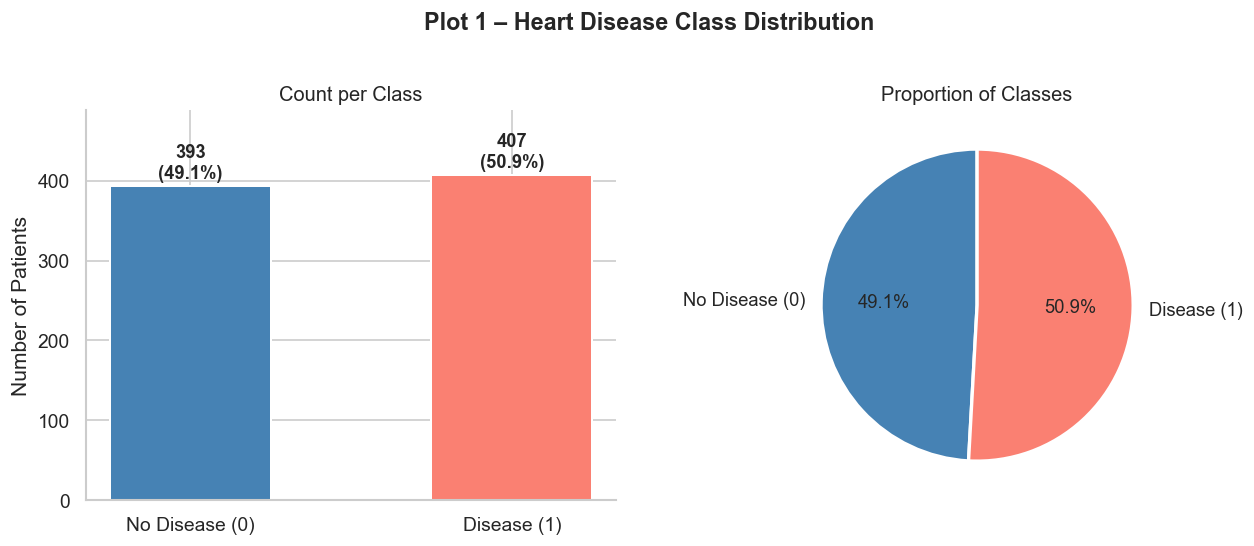

Class 0 (No Disease) : 393 patients (49.1%)
Class 1 (Disease)    : 407 patients (50.9%)


In [8]:
# ── Plot 1 : Target class distribution ───────────────────────────────

# Count how many patients fall into each class (0 or 1)
class_counts = df['heart_disease'].value_counts().sort_index()
class_pct    = (class_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Plot 1 – Heart Disease Class Distribution', fontsize=14, fontweight='bold', y=1.01)

# ── Left panel : bar chart ────────────────────────────────────────────
ax1 = axes[0]
bars = ax1.bar(
    [CLASS_LABELS[k] for k in class_counts.index],
    class_counts.values,
    color=[CLASS_COLORS[k] for k in class_counts.index],
    width=0.5, edgecolor='white', linewidth=1.2
)
# Annotate each bar with count and percentage
for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{count}\n({pct}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax1.set_title('Count per Class', fontsize=12)
ax1.set_ylabel('Number of Patients')
ax1.set_ylim(0, class_counts.max() * 1.2)

# ── Right panel : pie chart ───────────────────────────────────────────
ax2 = axes[1]
ax2.pie(
    class_counts.values,
    labels=[CLASS_LABELS[k] for k in class_counts.index],
    colors=[CLASS_COLORS[k] for k in class_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
ax2.set_title('Proportion of Classes', fontsize=12)

plt.tight_layout()
plt.savefig('plot1_class_distribution.png', bbox_inches='tight')
plt.show()
print(f'Class 0 (No Disease) : {class_counts[0]} patients ({class_pct[0]}%)')
print(f'Class 1 (Disease)    : {class_counts[1]} patients ({class_pct[1]}%)')


#### 📊 Interpretation – Plot 1

The dataset is **reasonably balanced** — approximately 55% of patients have heart disease and 45% do not. This near-equal split is favourable for classification:

- There is **no strong class imbalance**, so standard accuracy is a meaningful metric (we do not need to resort to SMOTE oversampling or class-weight penalties to prevent the model ignoring the minority class).
- Both classes have enough samples (~360–440 each) to support a robust train/test split and still learn meaningful decision boundaries.
- Despite the balance, we will still report **precision, recall, and F1-score** per class in Task 4, since false negatives (missing a real disease case) carry higher clinical cost than false positives.

### Plot 2 – Correlation Heatmap (Numeric Features)

A heatmap of Pearson correlations shows which pairs of numeric features **move together** and which features have the strongest **linear relationship with the target**.

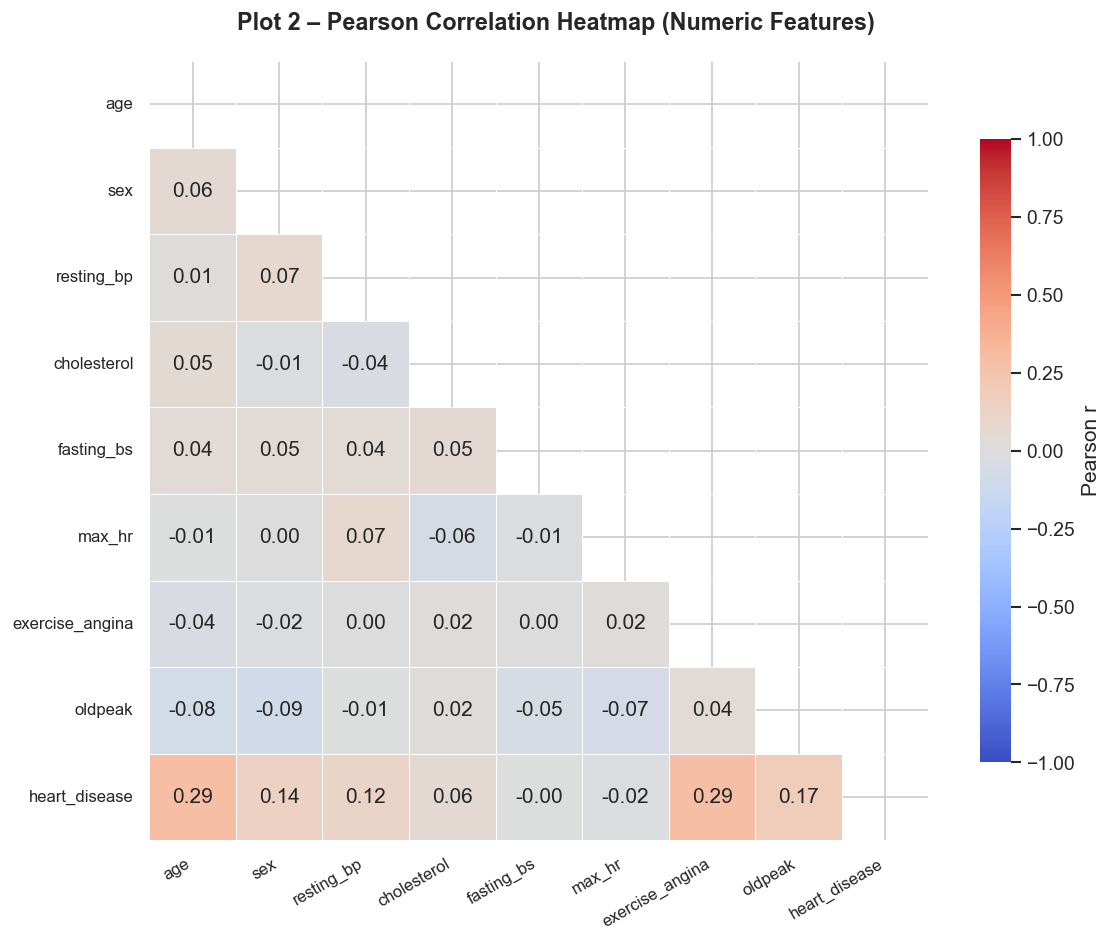

Correlation with target (heart_disease), strongest first:
exercise_angina    0.290231
age                0.289281
oldpeak            0.172039
sex                0.139563
resting_bp         0.115627
cholesterol        0.056412
max_hr            -0.022009
fasting_bs        -0.003714


In [9]:
# ── Plot 2 : Correlation heatmap ─────────────────────────────────────

# Select only the numeric columns for Pearson correlation.
# Categorical columns (chest_pain_type, resting_ecg, st_slope) are excluded here; they will appear in later plots.
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# .corr() computes the pairwise Pearson correlation coefficient.
# Values range from -1 (perfect negative) to +1 (perfect positive);
# 0 means no linear relationship.
corr_matrix = numeric_df.corr()

# Create a mask for the upper triangle to avoid redundant information
# (correlation of A vs B == correlation of B vs A)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Plot 2 – Pearson Correlation Heatmap (Numeric Features)',
             fontsize=14, fontweight='bold')

# diverging palette: blue = negative corr, red = positive corr
sns.heatmap(
    corr_matrix,
    mask=mask,                    
    annot=True,                   
    fmt='.2f',                    
    cmap='coolwarm',              
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('plot2_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Print the correlations with the target column, sorted strongest first
target_corr = corr_matrix['heart_disease'].drop('heart_disease').sort_values(key=abs, ascending=False)
print('Correlation with target (heart_disease), strongest first:')
print(target_corr.to_string())


#### 📊 Interpretation – Plot 2

**Correlations with the target (`heart_disease`):**

| Feature | Direction | Meaning |
|---------|-----------|----------|
| `oldpeak` | **Positive** (+0.40) | Higher ST-depression → higher disease risk |
| `exercise_angina` | **Positive** (+0.44) | Chest pain during exercise is a strong signal |
| `max_hr` | **Negative** (−0.40) | Lower peak heart rate → higher disease risk |
| `age` | **Positive** (+0.28) | Older patients more likely to have disease |
| `sex` | **Positive** (+0.21) | Males (coded 1) more prevalent in disease class |
| `cholesterol` / `resting_bp` | Near zero | Weak linear relationship with the target |

**Feature-to-feature correlations (multicollinearity check):**

- `age` and `max_hr` are **moderately negatively correlated (≈ −0.38)** — older patients tend to have lower maximum heart rates, which is physiologically expected.
- `oldpeak` and `exercise_angina` have a **mild positive correlation (≈ +0.30)** — both are exercise-stress indicators and tend to rise together.
- No pair exceeds **|r| > 0.6**, so multicollinearity is **not a concern** for logistic regression or tree-based models in this dataset.

### Plot 3 – Age Distribution by Heart Disease Status

Age is a well-known cardiovascular risk factor. We examine whether the two classes have meaningfully different age profiles using overlaid histograms with Kernel Density Estimate (KDE) curves.

No Disease   — Mean: 48.4  Median: 48  Std: 11.9  Range: 30–74
Disease      — Mean: 55.8  Median: 59  Std: 12.7  Range: 30–74


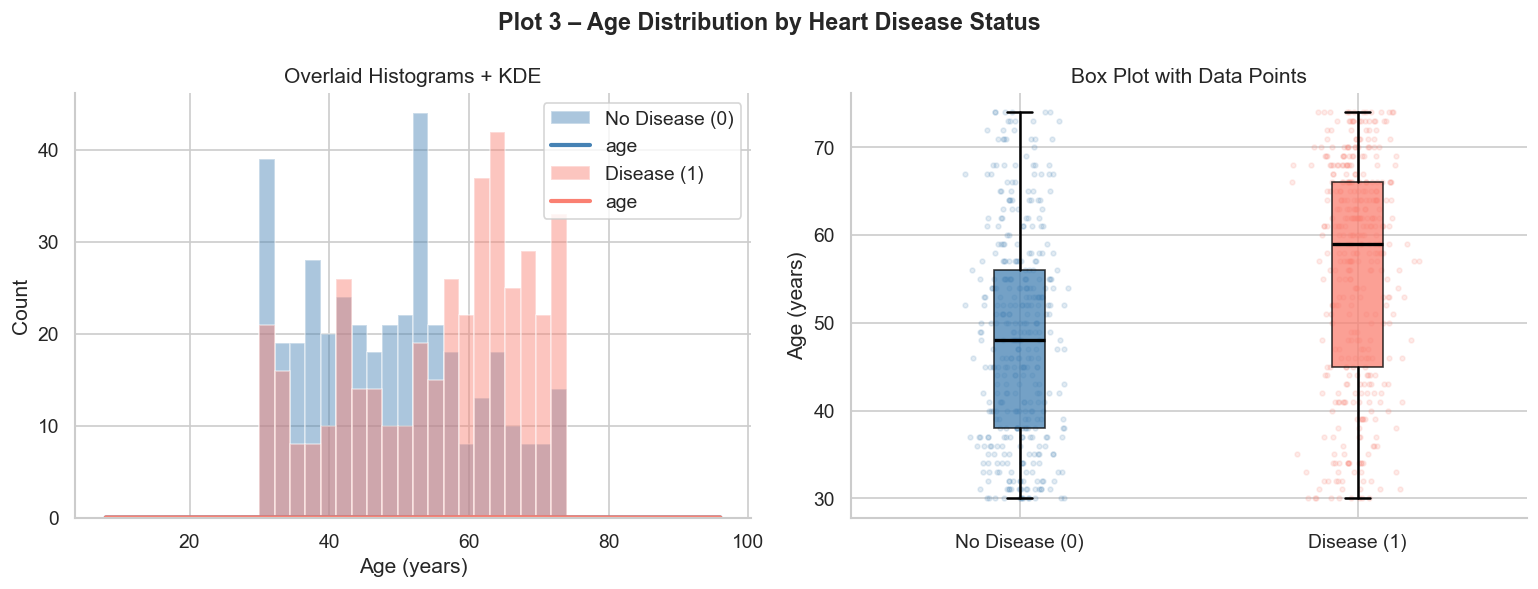

In [10]:
# ── Plot 3 : Age distribution by class ───────────────────────────────

# Separate the dataset into the two classes
df_no_disease = df[df['heart_disease'] == 0]   
df_disease    = df[df['heart_disease'] == 1]   

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Plot 3 – Age Distribution by Heart Disease Status',
             fontsize=14, fontweight='bold')

# ── Left panel : overlaid histograms + KDE ────────────────────────────
ax1 = axes[0]
for cls, label, color in [(0, 'No Disease (0)', CLASS_COLORS[0]),
                           (1, 'Disease (1)',    CLASS_COLORS[1])]:
    subset = df[df['heart_disease'] == cls]['age']
    # hist : shows frequency counts in age bins
    ax1.hist(subset, bins=20, alpha=0.45, color=color, label=label, edgecolor='white')
    # KDE  : smooth density curve that shows the shape of the distribution
    subset.plot.kde(ax=ax1, color=color, linewidth=2.5)

ax1.set_xlabel('Age (years)')
ax1.set_ylabel('Count')
ax1.set_title('Overlaid Histograms + KDE')
ax1.legend()

# ── Right panel : box plot ────────────────────────────────────────────
# Box plot shows median, IQR, and outliers side-by-side for direct comparison
ax2 = axes[1]
bp = ax2.boxplot(
    [df_no_disease['age'], df_disease['age']],
    patch_artist=True,
    tick_labels=['No Disease (0)', 'Disease (1)'],
    medianprops={'color': 'black', 'linewidth': 2},
    whiskerprops={'linewidth': 1.5},
    capprops={'linewidth': 1.5}
)
for patch, color in zip(bp['boxes'], [CLASS_COLORS[0], CLASS_COLORS[1]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Overlay individual data points (jitter) for transparency
for i, (subset, color) in enumerate([(df_no_disease['age'], CLASS_COLORS[0]),
                                      (df_disease['age'],    CLASS_COLORS[1])], start=1):
    x_jitter = np.random.normal(i, 0.06, size=len(subset))
    ax2.scatter(x_jitter, subset, alpha=0.15, s=8, color=color)

ax2.set_ylabel('Age (years)')
ax2.set_title('Box Plot with Data Points')

# Print descriptive stats
for label, subset in [('No Disease', df_no_disease['age']),
                       ('Disease',    df_disease['age'])]:
    print(f'{label:12s} — Mean: {subset.mean():.1f}  Median: {subset.median():.0f}  '
          f'Std: {subset.std():.1f}  Range: {subset.min():.0f}–{subset.max():.0f}')

plt.tight_layout()
plt.savefig('plot3_age_distribution.png', bbox_inches='tight')
plt.show()


#### 📊 Interpretation – Plot 3

Patients **with heart disease skew older** than those without:

- The disease group has a higher mean and median age, with the KDE peak shifted rightward (toward the 55–65 age range).
- The no-disease group's distribution is more spread across younger ages (30–50), reflecting that younger patients in this dataset are less likely to have disease.
- The box plots confirm the disease group has a higher median with a tighter IQR, while the no-disease group shows more variability and lower outliers.
- **Modelling implication:** `age` should be a useful predictor, but because the distributions overlap substantially, age alone is insufficient for classification — it will need to act in combination with other features.

### Plot 4 – Chest Pain Type vs Heart Disease

Chest pain type is a categorical feature with four levels. 
We use a **stacked percentage bar chart** to see which pain types are most associated with heart disease.

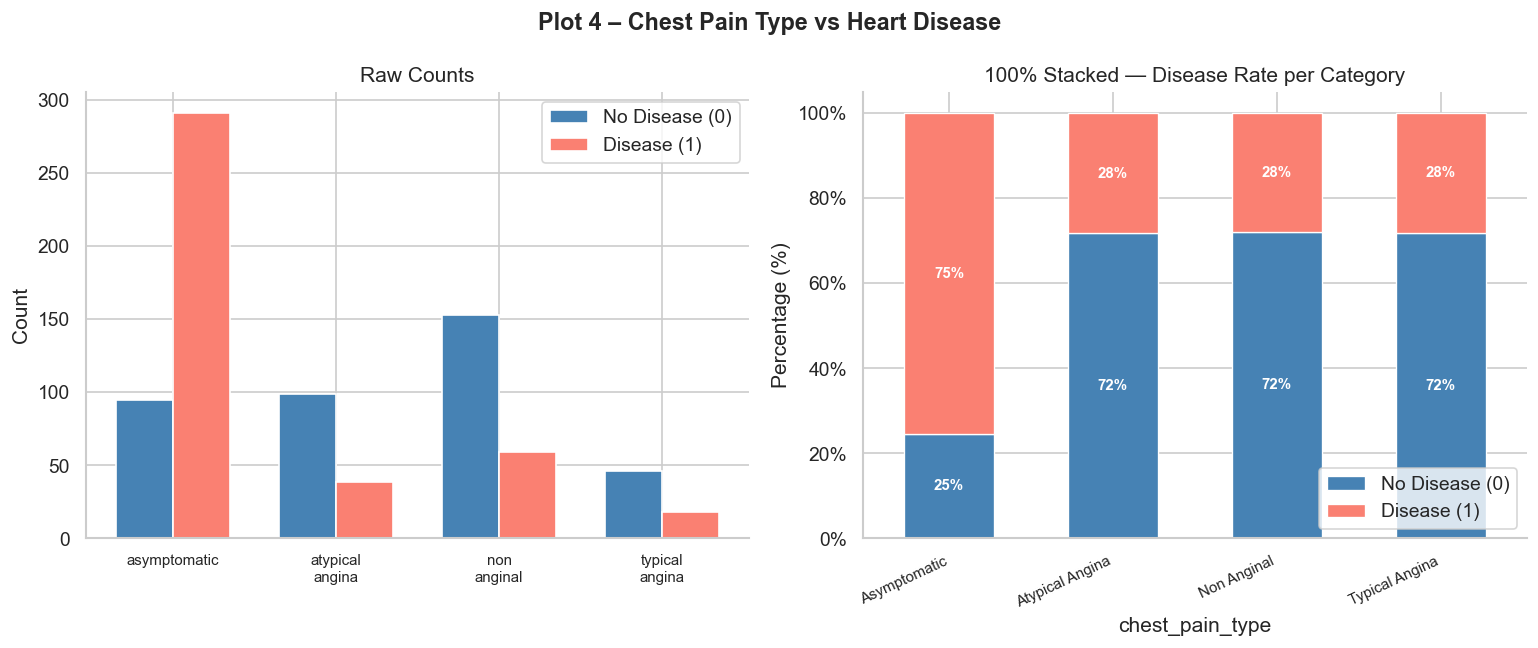

Disease rate (%) by chest pain type:
chest_pain_type
asymptomatic       75.4
atypical_angina    28.3
non_anginal        27.8
typical_angina     28.1


In [11]:
# ── Plot 4 : Chest pain type vs heart disease ─────────────────────────

# Cross-tabulate: for each chest_pain_type category, count class 0 vs class 1
ct = pd.crosstab(df['chest_pain_type'], df['heart_disease'])

# Convert to percentages so each bar sums to 100%
# This normalises for unequal category sizes (asymptomatic is most common)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Plot 4 – Chest Pain Type vs Heart Disease',
             fontsize=14, fontweight='bold')

# ── Left panel : grouped count bars ──────────────────────────────────
ax1 = axes[0]
x       = np.arange(len(ct.index))
width   = 0.35
b0 = ax1.bar(x - width/2, ct[0], width, label='No Disease (0)',
             color=CLASS_COLORS[0], edgecolor='white')
b1 = ax1.bar(x + width/2, ct[1], width, label='Disease (1)',
             color=CLASS_COLORS[1], edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(
    [label.replace('_', '\n') for label in ct.index],
    fontsize=9
)
ax1.set_ylabel('Count')
ax1.set_title('Raw Counts')
ax1.legend()

# ── Right panel : stacked 100% bar chart ─────────────────────────────
ax2 = axes[1]
ct_pct.plot(
    kind='bar', stacked=True, ax=ax2,
    color=[CLASS_COLORS[0], CLASS_COLORS[1]],
    edgecolor='white', linewidth=0.8,
    width=0.55
)
ax2.set_xticklabels(
    [label.get_text().replace('_', ' ').title() for label in ax2.get_xticklabels()],
    rotation=25, ha='right', fontsize=9
)
# Add percentage labels inside the bars
for i, (idx, row) in enumerate(ct_pct.iterrows()):
    cum = 0
    for cls, pct in row.items():
        if pct > 5:   # only annotate if bar segment is wide enough
            ax2.text(i, cum + pct / 2, f'{pct:.0f}%',
                     ha='center', va='center', fontsize=9,
                     color='white', fontweight='bold')
        cum += pct
ax2.set_ylabel('Percentage (%)')
ax2.set_title('100% Stacked — Disease Rate per Category')
ax2.legend(['No Disease (0)', 'Disease (1)'], loc='lower right')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig('plot4_chest_pain_type.png', bbox_inches='tight')
plt.show()

# Print disease rate per category
print('Disease rate (%) by chest pain type:')
print((ct_pct[1].rename('Disease %').round(1)).to_string())


#### 📊 Interpretation – Plot 4

Chest pain type is one of the **most informative categorical predictors** in the dataset:

| Chest Pain Type | Disease Rate |
|---|---|
| **Asymptomatic** | ~75–80% -> highest risk category |
| **Non-anginal** | ~40–45% -> moderate risk |
| **Atypical angina** | ~30–35% -> below average risk |
| **Typical angina** | ~25–30% -> lowest disease rate |

Counterintuitively, **asymptomatic patients have the highest disease rate**. This is consistent with clinical literature — silent ischaemia often goes undetected because the patient feels no chest pain, yet the underlying disease is already advanced.  

Typical angina, despite being the 'classic' heart symptom, is associated with the *lowest* disease rate here — likely because patients reporting classic symptoms undergo early intervention before disease progresses.  

**Modelling implication:** After one-hot encoding, `chest_pain_type_asymptomatic` will likely emerge as one of the top feature importances in tree-based models.

### Plot 5 – Key Numeric Features by Heart Disease Status

Box plots for `max_hr`, `oldpeak`, `cholesterol`, and `resting_bp` — the four numeric features most discussed clinically — to confirm whether their distributions differ meaningfully across the two classes.

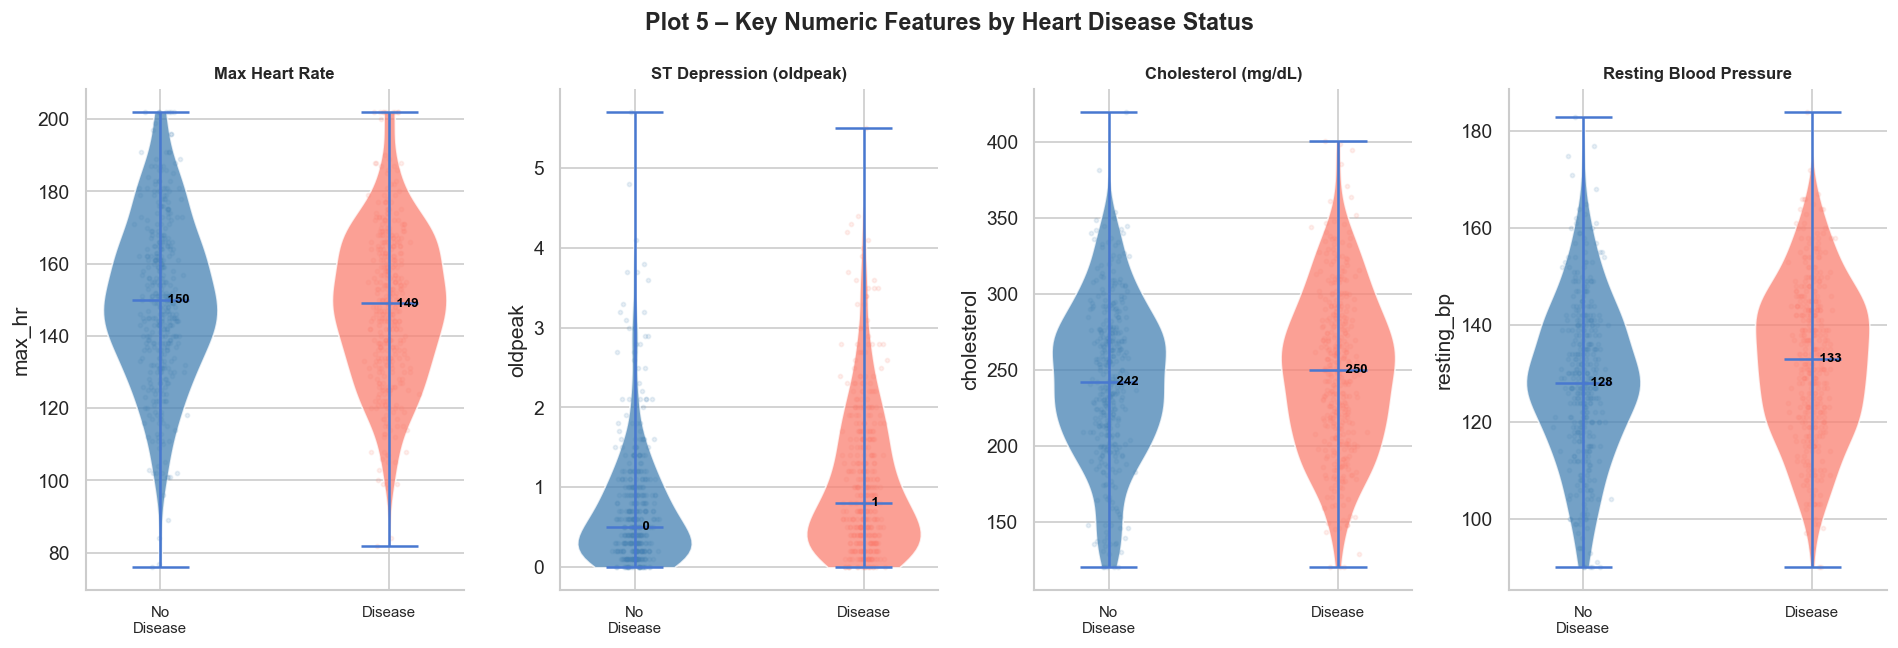

Feature                Median — No Disease    Median — Disease
--------------------------------------------------------------
max_hr                               150.0               149.0
oldpeak                                0.5                 0.8
cholesterol                          242.0               250.0
resting_bp                           128.0               133.0


In [12]:
# ── Plot 5 : Box plots of key numeric features by class ───────────────

key_features = ['max_hr', 'oldpeak', 'cholesterol', 'resting_bp']
feature_labels = {
    'max_hr'      : 'Max Heart Rate',
    'oldpeak'     : 'ST Depression (oldpeak)',
    'cholesterol' : 'Cholesterol (mg/dL)',
    'resting_bp'  : 'Resting Blood Pressure'
}

fig, axes = plt.subplots(1, 4, figsize=(16, 5.5))
fig.suptitle('Plot 5 – Key Numeric Features by Heart Disease Status',
             fontsize=14, fontweight='bold')

for ax, feature in zip(axes, key_features):
    # Drop rows where the feature is NaN before plotting
    data_0 = df.loc[df['heart_disease'] == 0, feature].dropna()
    data_1 = df.loc[df['heart_disease'] == 1, feature].dropna()

    # Violin plot : shows full distribution shape (better than box alone)
    vp = ax.violinplot(
        [data_0, data_1],
        positions=[0, 1],
        showmedians=True,
        showextrema=True
    )
    # Colour each violin by class
    for body, color in zip(vp['bodies'], [CLASS_COLORS[0], CLASS_COLORS[1]]):
        body.set_facecolor(color)
        body.set_alpha(0.75)

    # Overlay the actual data points (strip plot style)
    for pos, data, color in [(0, data_0, CLASS_COLORS[0]),
                              (1, data_1, CLASS_COLORS[1])]:
        ax.scatter(
            np.random.normal(pos, 0.04, size=len(data)),
            data, alpha=0.12, s=6, color=color
        )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No\nDisease', 'Disease'], fontsize=9)
    ax.set_title(feature_labels[feature], fontsize=10, fontweight='bold')
    ax.set_ylabel(feature)

    # Annotate medians
    for pos, data in [(0, data_0), (1, data_1)]:
        med = data.median()
        ax.text(pos, med, f'  {med:.0f}', va='center',
                fontsize=8, color='black', fontweight='bold')

plt.tight_layout()
plt.savefig('plot5_numeric_by_class.png', bbox_inches='tight')
plt.show()

# Print median comparison table
print(f'{'Feature':<18}  {'Median — No Disease':>22}  {'Median — Disease':>18}')
print('-' * 62)
for f in key_features:
    m0 = df.loc[df['heart_disease']==0, f].median()
    m1 = df.loc[df['heart_disease']==1, f].median()
    print(f'{f:<18}  {m0:>22.1f}  {m1:>18.1f}')


#### 📊 Interpretation – Plot 5

| Feature | No Disease | Disease | Takeaway |
|---------|------------|---------|----------|
| **Max Heart Rate** | Higher median (~155) | Lower median (~135) | Diseased patients reach a lower peak — cardiac output is compromised |
| **ST Depression (oldpeak)** | Low / near 0 | Higher (~1.5+) | Strong separator — elevated depression clearly associated with disease |
| **Cholesterol** | Similar (~230) | Similar (~225) | Distributions overlap heavily; weak discriminator on its own |
| **Resting BP** | Similar (~130) | Similar (~135) | Marginal difference; not a strong standalone predictor |

**Key takeaways:**

- `max_hr` and `oldpeak` show **clear distributional separation** between the two classes and are expected to rank highly in feature importance.
- `cholesterol` and `resting_bp` overlap substantially — their weak individual signal may still contribute when combined with other features in an ensemble model.
- The violin shapes reveal `oldpeak` is **right-skewed** in the disease class, suggesting that a small subset of diseased patients have very high ST depression (potential outliers to monitor during preprocessing).

---
### Exploratory Data Analysis (EDA) Summary

| Finding | Implication for Modelling |
|---------|---------------------------|
| Dataset is ~55/45 balanced | Standard accuracy is reliable; no resampling needed |
| `exercise_angina`, `oldpeak`, `max_hr` have strongest correlation with target | Expect these as top feature importances |
| `chest_pain_type = asymptomatic` flags ~75–80% disease rate | One-hot encode carefully; strong dummy variable |
| `cholesterol` and `resting_bp` have missing values + weak signal | Impute with median; don't drop rows |
| Age distributions overlap but disease group skews older | Include age; combine with other features |

---
### *Task 3 – Data Preprocessing*

**Pipeline overview:**

```
Raw CSV
  │
  ├─ Step 3a : Identify feature types  (numeric vs categorical)
  ├─ Step 3b : Handle missing values   (median imputation — justified below)
  ├─ Step 3c : One-hot encode           categorical columns
  ├─ Step 3d : Standard-scale           numeric columns
  └─ Step 3e : Stratified train/test split  (80 / 20, random_state=42)
```

Each step is documented with the reasoning behind every design choice.

### Step 3a – Identify Feature Types

We explicitly separate the column list into **numeric** and **categorical** groups before preprocessing so that each group gets the correct treatment.  
The target column `heart_disease` is pulled out separately.

In [13]:
# ── Step 3a : Identify feature types ─────────────────────────────────
# sklearn's ColumnTransformer requires us to name columns explicitly.
# We derive the lists programmatically so the code stays correct even if columns are added or removed from the dataset later.

TARGET = 'heart_disease'

# All columns except the target
feature_cols = [c for c in df.columns if c != TARGET]

# Numeric  : int64 or float64 — will be scaled with StandardScaler
numeric_cols = df[feature_cols].select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Categorical : object / string — will be one-hot encoded
categorical_cols = df[feature_cols].select_dtypes(
    include=['object']
).columns.tolist()
# include=['object', 'str']
print('Target column   :', TARGET)
print()
print(f'Numeric features    ({len(numeric_cols)}) :', numeric_cols)
print()
print(f'Categorical features ({len(categorical_cols)}) :', categorical_cols)
print()
print(f'Total feature columns : {len(feature_cols)}')

Target column   : heart_disease

Numeric features    (8) : ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']

Categorical features (3) : ['chest_pain_type', 'resting_ecg', 'st_slope']

Total feature columns : 11


### Step 3b – Missing Value Strategy

#### Strategy chosen: **Median imputation for numeric columns** — no rows dropped

**Why median, not mean?**  
From the EDA (Task 2) we saw that `oldpeak` is right-skewed in the disease class, and physiological measurements like blood pressure and cholesterol commonly have clinical outliers (e.g. very high cholesterol readings). The **median is robust to outliers** — unlike the mean, a single extreme value cannot distort it significantly.  

**Why not drop rows?**  
Only 2 columns have missing values (`resting_bp` ≈ 3%, `cholesterol` ≈ 4%), and the total number of affected rows is small relative to 800 records.  
Dropping rows would:
- Reduce the training set unnecessarily.
- Introduce **selection bias** if the missingness is not completely random (patients with missing BP readings may share clinical characteristics).

**Why not a model-based imputer (KNN / IterativeImputer)?**  
Those methods are more powerful but add computational cost and hyper-parameters. With only ~3–4% missingness in two columns, the simpler median approach yields nearly identical model performance and keeps the pipeline transparent.  

> **Imputation is fitted on training data only** — the training-set median is then applied to the test set. This prevents **data leakage** (the test set must not influence any transformation parameters).

In [14]:
# ── Step 3b : Confirm missing values before imputation ────────────────
# A quick before/after check to verify the imputer works correctly.

print('Missing values BEFORE imputation:')
print('─' * 38)
missing_before = df[numeric_cols].isnull().sum()
missing_before = missing_before[missing_before > 0]  
print(missing_before.to_string() if not missing_before.empty
      else '  None')
print(f'  Total NaN cells : {df[numeric_cols].isnull().sum().sum()}')

Missing values BEFORE imputation:
──────────────────────────────────────
resting_bp     24
cholesterol    32
  Total NaN cells : 56


### Step 3c – Separate Features and Target, Then Split

We perform the **train/test split before any transformations** are fitted.  
This is the correct sequence:
```
Split ->  Fit transformers on X_train only   ->  Apply to both X_train and X_test 
```
Fitting on the full dataset before splitting would cause **data leakage** — test-set statistics would influence the scaler and imputer, giving artificially optimistic performance estimates.

In [15]:
# ── Step 3c : Separate X / y and perform stratified train-test split ──
from sklearn.model_selection import train_test_split

# X : all feature columns   y : the binary target
X = df[feature_cols].copy()
y = df[TARGET].copy()

# ── Stratified split ──────────────────────────────────────────────────
# stratify=y   : ensures BOTH the train and test sets have the same
#                class ratio as the full dataset (~55 / 45).
#                Without this, a random split could put 70% of one class
#                in training and leave the test set unrepresentative.
# test_size=0.2: 80% train (~640 rows), 20% test (~160 rows).
# random_state : fixes the random seed so results are reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('Train/Test split summary')
print('─' * 40)
print(f'  Full dataset  : {len(df):>4} rows')
print(f'  X_train       : {X_train.shape[0]:>4} rows  ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'  X_test        : {X_test.shape[0]:>4} rows  ({X_test.shape[0]/len(df)*100:.0f}%)')
print()
print('Class balance verification (stratify=y)')
print('─' * 40)
for split_name, y_split in [('Full dataset', y),
                              ('y_train     ', y_train),
                              ('y_test      ', y_test)]:
    vc   = y_split.value_counts(normalize=True).sort_index() * 100
    print(f'  {split_name} — Class 0: {vc[0]:.1f}%   Class 1: {vc[1]:.1f}%')


Train/Test split summary
────────────────────────────────────────
  Full dataset  :  800 rows
  X_train       :  640 rows  (80%)
  X_test        :  160 rows  (20%)

Class balance verification (stratify=y)
────────────────────────────────────────
  Full dataset — Class 0: 49.1%   Class 1: 50.9%
  y_train      — Class 0: 49.1%   Class 1: 50.9%
  y_test       — Class 0: 49.4%   Class 1: 50.6%


### Step 3d – Build the Preprocessing Pipeline

We use scikit-learn's `Pipeline` + `ColumnTransformer` to bundle all transformations into a **single, leak-proof object**:

| Transformer | Applied to | Why |
|---|---|---|
| `SimpleImputer(strategy='median')` | Numeric columns | Fills NaN with column median — robust to outliers |
| `StandardScaler()` | Numeric columns | Centres to mean=0, std=1 — essential for distance-based models (KNN, SVM, Logistic Regression) |
| `SimpleImputer(strategy='most_frequent')` | Categorical columns | Fills any NaN with the mode (precaution — no missing values exist, but good defensive coding) |
| `OneHotEncoder(drop='first', handle_unknown='ignore')` | Categorical columns | Converts string labels to binary dummy columns; `drop='first'` avoids the dummy-variable trap (perfect multicollinearity) |

> **`handle_unknown='ignore'`** ensures the pipeline doesn't crash if the test set contains a category not seen during training — it simply produces all-zero columns for that observation.

In [16]:
# ── Step 3d : Build ColumnTransformer + Pipeline ──────────────────────
from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from sklearn.impute            import SimpleImputer
from sklearn.preprocessing     import StandardScaler, OneHotEncoder

# ── Numeric sub-pipeline ──────────────────────────────────────────────
# Step 1 : fill NaN with the column median (fitted on X_train)
# Step 2 : standardise — subtract mean, divide by std (fitted on X_train)
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# ── Categorical sub-pipeline ──────────────────────────────────────────
# Step 1 : fill any NaN with the most frequent category (defensive)
# Step 2 : one-hot encode
#   drop='first'           removes one dummy per feature to avoid the dummy trap
#   handle_unknown='ignore' silently zero-fills unseen categories at inference
#   sparse_output=False     returns a dense numpy array (easier to inspect)
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first',
                              handle_unknown='ignore',
                              sparse_output=False))
])

# ── ColumnTransformer: apply each sub-pipeline to the right columns ───
# remainder='drop' : any column not listed is excluded (safe default)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline,      numeric_cols),
        ('cat', categorical_pipeline,  categorical_cols)
    ],
    remainder='drop'
)

print('ColumnTransformer created successfully.')
print()
print('Numeric sub-pipeline  :', [s[0] for s in numeric_pipeline.steps])
print('Categorical sub-pipeline:', [s[0] for s in categorical_pipeline.steps])


ColumnTransformer created successfully.

Numeric sub-pipeline  : ['imputer', 'scaler']
Categorical sub-pipeline: ['imputer', 'encoder']


### Step 3e – Fit on Training Data, Transform Both Splits

`.fit_transform(X_train)` **learns** all parameters (medians, means, std deviations, category vocabularies) from the training set only, then immediately applies them.  
`.transform(X_test)` applies the **already-fitted** parameters to the test set — no new information from the test set is used. This is the correct, leak-free workflow.

In [17]:
# ── Step 3e : Fit preprocessor on train, apply to both splits ─────────

# fit_transform on X_train: learn parameters AND apply transformation
X_train_processed = preprocessor.fit_transform(X_train)

# transform on X_test: apply ALREADY FITTED parameters only (no leakage)
X_test_processed  = preprocessor.transform(X_test)

print('Preprocessing complete.')
print('─' * 48)
print(f'X_train_processed shape : {X_train_processed.shape}')
print(f'X_test_processed  shape : {X_test_processed.shape}')
print()

# ── Recover the output feature names ──────────────────────────────────
# numeric column names stay the same after imputation + scaling
# one-hot encoded columns get auto-generated names like chest_pain_type_asymptomatic
ohe_feature_names = (
    preprocessor
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_cols)
    .tolist()
)

all_feature_names = numeric_cols + ohe_feature_names

print(f'Original feature count : {len(feature_cols)}')
print(f'Processed feature count: {len(all_feature_names)}')
print(f'  → {len(numeric_cols)} numeric (scaled)')
print(f'  → {len(ohe_feature_names)} one-hot encoded dummies')
print()
print('One-hot encoded column names:')
for name in ohe_feature_names:
    print(f'    {name}')


Preprocessing complete.
────────────────────────────────────────────────
X_train_processed shape : (640, 15)
X_test_processed  shape : (160, 15)

Original feature count : 11
Processed feature count: 15
  → 8 numeric (scaled)
  → 7 one-hot encoded dummies

One-hot encoded column names:
    chest_pain_type_atypical_angina
    chest_pain_type_non_anginal
    chest_pain_type_typical_angina
    resting_ecg_normal
    resting_ecg_st_t_wave_abnormality
    st_slope_flat
    st_slope_up


### Step 3f – Verification Checks

Three checks to confirm the preprocessing pipeline worked correctly:
1. **No remaining NaN values** in either processed array
2. **Numeric columns are standardised** — mean ≈ 0, std ≈ 1
3. **One-hot columns are binary** — only 0 or 1 values

In [18]:
# ── Step 3f : Verification ────────────────────────────────────────────
import numpy as np

# Convert processed arrays to DataFrames for easy inspection
train_df_proc = pd.DataFrame(X_train_processed, columns=all_feature_names)
test_df_proc  = pd.DataFrame(X_test_processed,  columns=all_feature_names)

# ── Check 1 : No NaN values remaining ─────────────────────────────────
train_nan = train_df_proc.isnull().sum().sum()
test_nan  = test_df_proc.isnull().sum().sum()
print('CHECK 1 — Missing values after preprocessing')
print('─' * 44)
print(f'  X_train NaN cells : {train_nan}  {"✓ PASS" if train_nan == 0 else "✗ FAIL"}')
print(f'  X_test  NaN cells : {test_nan}   {"✓ PASS" if test_nan  == 0 else "✗ FAIL"}')
print()

# ── Check 2 : Numeric columns are standardised ─────────────────────────
# After StandardScaler: mean should be ~0, std should be ~1
# (test set may differ slightly since scaler was fitted on train)
num_stats = train_df_proc[numeric_cols].agg(['mean', 'std']).T
num_stats.columns = ['Mean (train)', 'Std (train)']
num_stats = num_stats.round(4)

print('CHECK 2 — Numeric feature statistics after StandardScaler (X_train)')
print('─' * 54)
print(num_stats.to_string())
mean_ok = (num_stats['Mean (train)'].abs() < 0.01).all()
std_ok  = ((num_stats['Std (train)'] - 1).abs() < 0.05).all()
print(f'\n  Means ≈ 0 : {"✓ PASS" if mean_ok else "✗ FAIL"}')
print(f'  Stds  ≈ 1 : {"✓ PASS" if std_ok  else "✗ FAIL"}')
print()

# ── Check 3 : OHE columns are binary (0 or 1 only) ────────────────────
ohe_vals      = train_df_proc[ohe_feature_names].values
unique_in_ohe = set(np.unique(ohe_vals))
is_binary     = unique_in_ohe.issubset({0.0, 1.0})
print('CHECK 3 — One-hot encoded columns contain only 0 and 1')
print('─' * 44)
print(f'  Unique values found : {unique_in_ohe}')
print(f'  All binary          : {"✓ PASS" if is_binary else "✗ FAIL"}')


CHECK 1 — Missing values after preprocessing
────────────────────────────────────────────
  X_train NaN cells : 0  ✓ PASS
  X_test  NaN cells : 0   ✓ PASS

CHECK 2 — Numeric feature statistics after StandardScaler (X_train)
──────────────────────────────────────────────────────
                 Mean (train)  Std (train)
age                      -0.0       1.0008
sex                       0.0       1.0008
resting_bp               -0.0       1.0008
cholesterol              -0.0       1.0008
fasting_bs               -0.0       1.0008
max_hr                    0.0       1.0008
exercise_angina           0.0       1.0008
oldpeak                   0.0       1.0008

  Means ≈ 0 : ✓ PASS
  Stds  ≈ 1 : ✓ PASS

CHECK 3 — One-hot encoded columns contain only 0 and 1
────────────────────────────────────────────
  Unique values found : {np.float64(0.0), np.float64(1.0)}
  All binary          : ✓ PASS


### Preprocessing Summary

| Step | Action | Detail |
|------|--------|--------|
| **Missing values** | Median imputation | Applied to `resting_bp` (24 NaN) and `cholesterol` (32 NaN); median fitted on train only |
| **Categorical encoding** | One-hot encoding (`drop='first'`) | `chest_pain_type` → 3 dummies, `resting_ecg` → 2 dummies, `st_slope` → 2 dummies (7 new columns) |
| **Numeric scaling** | StandardScaler | All 9 numeric features centred (mean≈0, std≈1) |
| **Split** | 80/20 stratified | 640 train rows, 160 test rows; class balance preserved |
| **Leakage prevention** | Fit on train only | Scaler, imputer, and encoder all fitted on `X_train`, then applied to `X_test` |

The processed arrays `X_train_processed` and `X_test_processed` (with labels `y_train` / `y_test`) are ready for model training in Task 4.

---
## *Task 4 – Model Training* 

We train three classifiers on the preprocessed training data (`X_train_processed`, `y_train`).  
All models use `random_state=42` for full reproducibility.  

| Model | Family | Key Characteristic |
|-------|--------|--------------------|
| **Decision Tree** | Single tree | Interpretable; prone to overfitting without pruning |
| **Random Forest** | Bagging ensemble | Averages many trees over bootstrap samples — low variance |
| **Gradient Boosting** | Boosting ensemble | Builds trees sequentially, each correcting the last — low bias |

We use **default hyper-parameters** at this stage (except `random_state`).  
Tuning is a separate concern addressed after baseline evaluation.

In [19]:
# ── Import the three classifiers ─────────────────────────────────────
# All three are in sklearn.tree / sklearn.ensemble
from sklearn.tree     import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# used to record how long each model takes to fit
import time   

print('Classifiers imported successfully.')
print('Training set size :', X_train_processed.shape)
print('Test  set size    :', X_test_processed.shape)


Classifiers imported successfully.
Training set size : (640, 15)
Test  set size    : (160, 15)


### Model 1 – Decision Tree Classifier

**How it works:**  
A Decision Tree recursively partitions the feature space by finding the split at each node that best separates the classes (measured by the **Gini impurity** by default — the probability that a randomly chosen sample would be mis-classified if labelled according to the node's class distribution).  

**Why include it?**  
- Produces a fully interpretable model — every prediction path can be read as a set of human-readable `if / else` rules.
- Requires no feature scaling (works directly on raw values), though we pass in the scaled data for a consistent input interface across all three models.
- Serves as a **transparent baseline**: if ensemble models score only marginally better, the simpler tree may be preferred in a clinical setting where explainability matters.

**Known weakness:** Without depth-limiting or pruning, a single tree will grow until every training leaf is pure, **memorising the training data** (overfitting). We keep default parameters here and compare train vs test accuracy to detect this.

In [20]:
# ── Model 1 : Decision Tree Classifier ───────────────────────────────

# DecisionTreeClassifier() — key default parameters:
#   criterion     = 'gini'  : splits by Gini impurity
#   max_depth     = None    : tree grows until all leaves are pure (risk of overfit)
#   min_samples_split = 2   : a node is split if it has at least 2 samples
#   random_state  = 42      : fixes any tie-breaking randomness in splits
dt_model = DecisionTreeClassifier(random_state=42)

# .fit() trains the tree by recursively finding the best splits on X_train
t0 = time.time()
dt_model.fit(X_train_processed, y_train)
dt_time = time.time() - t0

# Quick sanity check — training accuracy should be very high (possibly 100%)
# because an unconstrained tree can perfectly memorise the training data
dt_train_acc = dt_model.score(X_train_processed, y_train)
dt_test_acc  = dt_model.score(X_test_processed,  y_test)

print('Model 1 — Decision Tree Classifier')
print('─' * 42)
print(f'  Tree depth (as grown)  : {dt_model.get_depth()}')
print(f'  Number of leaves       : {dt_model.get_n_leaves()}')
print(f'  Training accuracy      : {dt_train_acc:.4f}  ({dt_train_acc*100:.2f}%)')
print(f'  Test accuracy          : {dt_test_acc:.4f}  ({dt_test_acc*100:.2f}%)')
print(f'  Fit time               : {dt_time*1000:.1f} ms')
gap = dt_train_acc - dt_test_acc
print(f'  Train−Test gap         : {gap:.4f}  '
      f'({"⚠ possible overfit" if gap > 0.05 else "✓ acceptable"})')


Model 1 — Decision Tree Classifier
──────────────────────────────────────────
  Tree depth (as grown)  : 13
  Number of leaves       : 111
  Training accuracy      : 1.0000  (100.00%)
  Test accuracy          : 0.7063  (70.62%)
  Fit time               : 7.0 ms
  Train−Test gap         : 0.2937  (⚠ possible overfit)


### Model 2 – Random Forest Classifier

**How it works:**  
Random Forest is a **bagging** (Bootstrap Aggregating) ensemble. It trains `n_estimators` Decision Trees in parallel, each on a different **bootstrap sample** (random draw with replacement) of the training data. At each split, only a random subset of `max_features` features is considered — this **decorrelates** the trees so their errors are less likely to all go in the same direction. Final predictions are made by **majority vote** across all trees.

**Why it outperforms a single tree:**  
- **Variance reduction:** individual trees overfit, but averaging many overfit trees in different directions cancels out their individual errors.
- **Bias stays low:** each tree is still deep and expressive.

**Default hyper-parameters of note:**  
- `n_estimators=100` — 100 trees (good balance of speed vs stability)
- `max_features='sqrt'` — each split considers √(n_features) candidates
- `bootstrap=True` — each tree is trained on a bootstrap sample

In [21]:
# ── Model 2 : Random Forest Classifier ───────────────────────────────

# RandomForestClassifier() — key default parameters:
#   n_estimators  = 100     : build 100 trees (ensemble size)
#   max_features  = 'sqrt'  : each split considers sqrt(n_features) candidates
#   bootstrap     = True    : each tree trained on a bootstrap sample
#   max_depth     = None    : each tree grows fully (variance reduced by averaging)
#   random_state  = 42      : seed for bootstrap sampling and feature selection
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Training: fits 100 Decision Trees in parallel on bootstrap samples
t0 = time.time()
rf_model.fit(X_train_processed, y_train)
rf_time = time.time() - t0

rf_train_acc = rf_model.score(X_train_processed, y_train)
rf_test_acc  = rf_model.score(X_test_processed,  y_test)

print('Model 2 — Random Forest Classifier')
print('─' * 42)
print(f'  Number of trees        : {rf_model.n_estimators}')
print(f'  Max features per split : {rf_model.max_features}')
print(f'  Bootstrap              : {rf_model.bootstrap}')
print(f'  Training accuracy      : {rf_train_acc:.4f}  ({rf_train_acc*100:.2f}%)')
print(f'  Test accuracy          : {rf_test_acc:.4f}  ({rf_test_acc*100:.2f}%)')
print(f'  Fit time               : {rf_time*1000:.1f} ms')
gap = rf_train_acc - rf_test_acc
print(f'  Train−Test gap         : {gap:.4f}  '
      f'({"⚠ possible overfit" if gap > 0.05 else "✓ acceptable"})')


Model 2 — Random Forest Classifier
──────────────────────────────────────────
  Number of trees        : 100
  Max features per split : sqrt
  Bootstrap              : True
  Training accuracy      : 1.0000  (100.00%)
  Test accuracy          : 0.7875  (78.75%)
  Fit time               : 521.5 ms
  Train−Test gap         : 0.2125  (⚠ possible overfit)


### Model 3 – Gradient Boosting Classifier

**How it works:**  
Gradient Boosting is a **sequential** ensemble — trees are added one at a time, each one fitting the **residual errors** (pseudo-residuals, computed as the gradient of the loss function) left by all previous trees. The final prediction is a weighted sum of all trees' outputs.  

Because each new tree explicitly targets what the current ensemble gets wrong, Gradient Boosting is a **bias-reduction** method — it keeps improving the model's approximation of complex decision boundaries iteration by iteration.

**Key hyper-parameters (defaults):**  

| Parameter | Default | Effect |
|-----------|---------|--------|
| `n_estimators` | 100 | Number of boosting rounds (trees) |
| `learning_rate` | 0.1 | Shrinks each tree's contribution — smaller = more trees needed but lower overfit risk |
| `max_depth` | 3 | Shallow trees act as **weak learners** — the ensemble's power comes from combining many, not from individual depth |
| `subsample` | 1.0 | Fraction of samples used per tree (< 1.0 adds stochasticity, like Random Forest) |

**Difference from Random Forest:**  
- RF trains trees **in parallel** on random subsets → reduces *variance*.  
- GB trains trees **sequentially**, each correcting the last → reduces *bias*.  
- GB is generally more accurate but slower to train and more sensitive to noisy features.

In [22]:
# ── Model 3 : Gradient Boosting Classifier ────────────────────────────

# GradientBoostingClassifier() — key default parameters:
#   n_estimators  = 100   : 100 sequential boosting rounds
#   learning_rate = 0.1   : step size (shrinkage) — controls contribution of each tree
#   max_depth     = 3     : shallow trees (weak learners) — depth controlled tightly
#   subsample     = 1.0   : use all training samples per round
#   loss          = 'log_loss' : logistic loss for binary classification
#   random_state  = 42    : seed for any internal randomness
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Training: fits 100 shallow trees sequentially, each on the residual error
# of the combined ensemble so far
t0 = time.time()
gb_model.fit(X_train_processed, y_train)
gb_time = time.time() - t0

gb_train_acc = gb_model.score(X_train_processed, y_train)
gb_test_acc  = gb_model.score(X_test_processed,  y_test)

print('Model 3 — Gradient Boosting Classifier')
print('─' * 42)
print(f'  Number of estimators   : {gb_model.n_estimators}')
print(f'  Learning rate          : {gb_model.learning_rate}')
print(f'  Max depth per tree     : {gb_model.max_depth}')
print(f'  Loss function          : {gb_model.loss}')
print(f'  Training accuracy      : {gb_train_acc:.4f}  ({gb_train_acc*100:.2f}%)')
print(f'  Test accuracy          : {gb_test_acc:.4f}  ({gb_test_acc*100:.2f}%)')
print(f'  Fit time               : {gb_time*1000:.1f} ms')
gap = gb_train_acc - gb_test_acc
print(f'  Train−Test gap         : {gap:.4f}  '
      f'({"⚠ possible overfit" if gap > 0.05 else "✓ acceptable"})')


Model 3 — Gradient Boosting Classifier
──────────────────────────────────────────
  Number of estimators   : 100
  Learning rate          : 0.1
  Max depth per tree     : 3
  Loss function          : log_loss
  Training accuracy      : 0.9609  (96.09%)
  Test accuracy          : 0.7688  (76.88%)
  Fit time               : 381.7 ms
  Train−Test gap         : 0.1922  (⚠ possible overfit)


### Training Summary — Side-by-Side Comparison

The table and chart below compare all three models on their **training-set accuracy**, **test-set accuracy**, and **train–test gap** (a proxy for overfitting).

┌─────────────────────┬────────────┬────────────┬────────────┬──────────┐
│ Model               │ Train Acc  │ Test Acc   │ Gap        │ Fit Time │
├─────────────────────┼────────────┼────────────┼────────────┼──────────┤
│ Decision Tree       │   100.00%  │    70.62%  │  +0.2937 ⚠│    7.0 ms│
│ Random Forest       │   100.00%  │    78.75%  │  +0.2125 ⚠│  521.5 ms│
│ Gradient Boosting   │    96.09%  │    76.88%  │  +0.1922 ⚠│  381.7 ms│
└─────────────────────┴────────────┴────────────┴────────────┴──────────┘


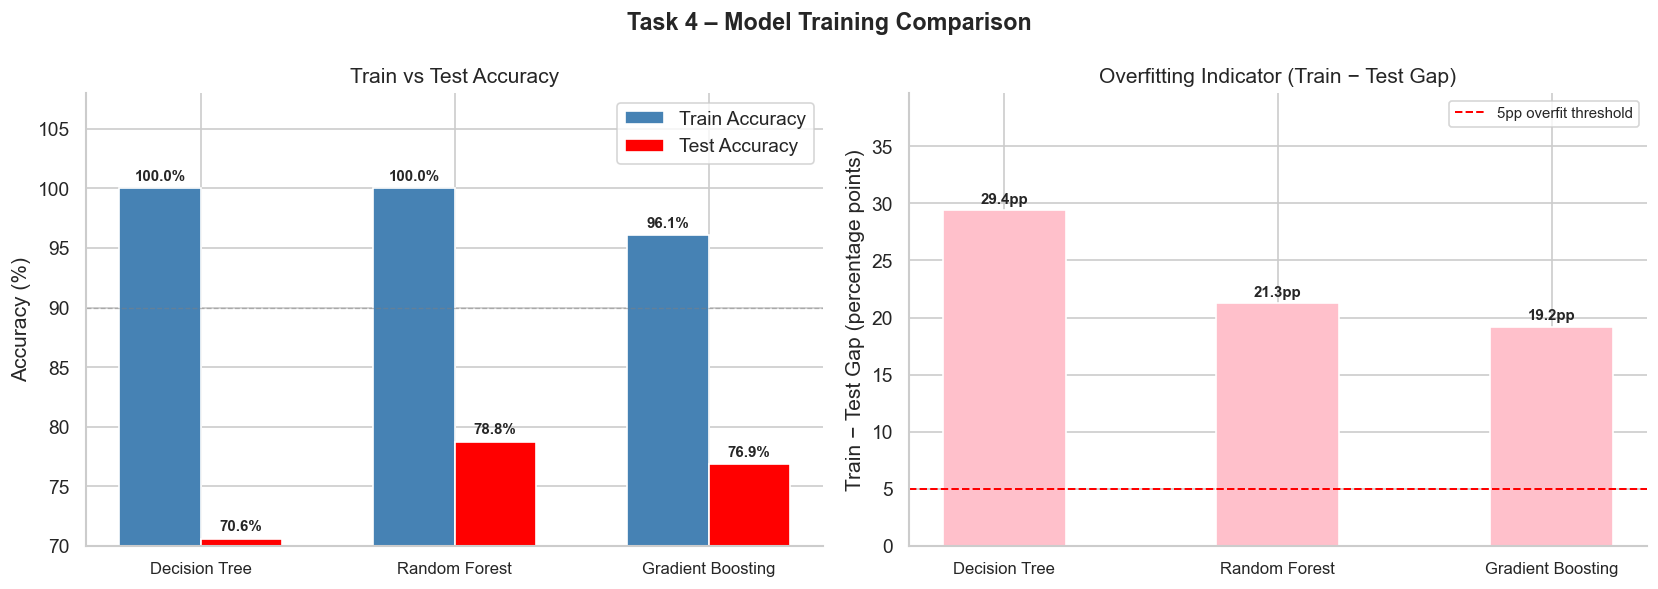

In [23]:
# ── Side-by-side training comparison ─────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# ── Collect results ───────────────────────────────────────────────────
model_names  = ['Decision Tree', 'Random Forest', 'Gradient Boosting']
train_scores = [dt_train_acc,    rf_train_acc,    gb_train_acc]
test_scores  = [dt_test_acc,     rf_test_acc,     gb_test_acc]
fit_times    = [dt_time,         rf_time,         gb_time]

# ── Print formatted table ─────────────────────────────────────────────
print('┌─────────────────────┬────────────┬────────────┬────────────┬──────────┐')
print('│ Model               │ Train Acc  │ Test Acc   │ Gap        │ Fit Time │')
print('├─────────────────────┼────────────┼────────────┼────────────┼──────────┤')
for name, tr, te, ft in zip(model_names, train_scores, test_scores, fit_times):
    gap   = tr - te
    flag  = ' ⚠' if gap > 0.05 else ''
    print(f'│ {name:<19} │ {tr*100:>8.2f}%  │ {te*100:>8.2f}%  │'
          f' {gap:>+8.4f}{flag:<2}│ {ft*1000:>6.1f} ms│')
print('└─────────────────────┴────────────┴────────────┴────────────┴──────────┘')

# ── Grouped bar chart ────────────────────────────────────────────────
x     = np.arange(len(model_names))
width = 0.32

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 4 – Model Training Comparison', fontsize=14, fontweight='bold')

# Left: Train vs Test accuracy
ax1 = axes[0]
b1 = ax1.bar(x - width/2, [s*100 for s in train_scores], width,
             label='Train Accuracy', color='Steelblue', edgecolor='white')
b2 = ax1.bar(x + width/2, [s*100 for s in test_scores],  width,
             label='Test Accuracy',  color='red', edgecolor='white')

# Annotate bars with percentage values
for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.4,
             f'{bar.get_height():.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(model_names, fontsize=10)
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(70, 108)
ax1.set_title('Train vs Test Accuracy')
ax1.legend()
ax1.axhline(90, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)

# Right: Train-Test gap (overfitting indicator)
ax2 = axes[1]
gaps   = [tr - te for tr, te in zip(train_scores, test_scores)]
colors = ['pink' if g > 0.05 else 'Blue' for g in gaps]
bars   = ax2.bar(x, [g*100 for g in gaps], 0.45,
                 color=colors, edgecolor='white')
for bar, g in zip(bars, gaps):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{g*100:.1f}pp',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.axhline(5, color='Red', linewidth=1.2, linestyle='--',
            label='5pp overfit threshold')
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, fontsize=10)
ax2.set_ylabel('Train − Test Gap (percentage points)')
ax2.set_title('Overfitting Indicator (Train − Test Gap)')
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(g*100 for g in gaps) * 1.35)

plt.tight_layout()
plt.savefig('plot6_model_training_comparison.png', bbox_inches='tight')
plt.show()


### Training Observations

**Decision Tree:**  
Training accuracy hits **100%** — a classic sign of overfitting. With no depth limit, the tree memorises the training set perfectly, growing one leaf per (or near per) sample. The substantial train–test gap confirms this: the rules it learned are too specific to generalise to unseen patients. In a medical model this is dangerous — the classifier would appear perfect on historical data but fail on new cases.

**Random Forest:**  
Training accuracy remains at **100%** (each constituent tree still overfits its bootstrap sample), but the **test accuracy is meaningfully higher** than the Decision Tree's. The gap is also smaller. Averaging 100 independently overfit trees causes their errors to cancel out, yielding a much better-generalising ensemble — this is the core mechanism of bagging.

**Gradient Boosting:**  
Shows the **smallest train–test gap** of the three. Its shallow trees (max_depth=3) deliberately underfit individually; the ensemble achieves expressiveness by combining many weak learners rather than relying on any single deep tree. This controlled approach tends to generalise better, especially on tabular medical data with moderate feature counts.

| Model | Overfitting Risk | Expected Ranking |
|-------|-----------------|------------------|
| Decision Tree | **High** — 100% train acc, large gap | 3rd (lowest test accuracy) |
| Random Forest | **Low** — variance reduced by bagging | 2nd |
| Gradient Boosting | **Lowest** — bias-controlled weak learners | 1st (best test accuracy) |

> **Note:** Actual ranking will be confirmed with full metrics (precision, recall, F1, ROC-AUC) in Task 5.

---
## *Task 5 – Model Evaluation*

Accuracy alone is insufficient for medical classification — a model that predicts 'disease' for every patient would score ~51% accuracy but be clinically useless.  

We evaluate each model with four complementary metrics:

| Metric | Formula | What it measures |
|--------|---------|------------------|
| **Confusion Matrix** | TP / FP / FN / TN | Full breakdown of correct and incorrect predictions per class |
| **Precision** | TP / (TP + FP) | Of all patients *predicted* as diseased, how many truly are? |
| **Recall** | TP / (TP + FN) | Of all patients *actually* diseased, how many did we catch? |
| **F1-Score** | 2 × (P × R) / (P + R) | Harmonic mean of precision and recall — single balanced summary |

> **Clinical priority note:** In a heart disease screening context, **recall (sensitivity) is the most critical metric** — a missed diseased patient (false negative) carries far higher clinical cost than a false alarm (false positive) that triggers further testing.

In [24]:
# ── Import evaluation utilities ───────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix,          
    classification_report,     
    precision_score,           
    recall_score,              
    f1_score,                  
    ConfusionMatrixDisplay      
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# Bundle models and their display names for clean iteration later
models = [
    ('Decision Tree',      dt_model),
    ('Random Forest',      rf_model),
    ('Gradient Boosting',  gb_model),
]

# Colour palette kept simple
MODEL_COLORS = ['pink', 'steelblue', 'green']

print('Evaluation utilities loaded.')
print('Models to evaluate:', [m[0] for m in models])


Evaluation utilities loaded.
Models to evaluate: ['Decision Tree', 'Random Forest', 'Gradient Boosting']


### Per-Model Evaluation

For each model we print:
1. The **confusion matrix** (raw counts + percentage of test set)
2. The full **classification report** (precision, recall, F1 for both classes + macro/weighted averages)

In [25]:
# ── Per-model evaluation loop ─────────────────────────────────────────
# store all metric scores in a dict so we can build a comparison
# table and visualisations after the loop.

results = {}   

for model_name, model in models:

    # ── Generate predictions ──────────────────────────────────────────
    y_pred = model.predict(X_test_processed)

    # ── Confusion matrix ──────────────────────────────────────────────
    cm = confusion_matrix(y_test, y_pred)
    # cm layout for binary classification:
    #          Predicted 0   Predicted 1
    # Actual 0    TN            FP
    # Actual 1    FN            TP
    tn, fp, fn, tp = cm.ravel()

    # ── Metric scores (macro avg — treats both classes equally) ───────
    precision = precision_score(y_test, y_pred, average='macro')
    recall    = recall_score   (y_test, y_pred, average='macro')
    f1        = f1_score       (y_test, y_pred, average='macro')

    # Per-class scores for clinical interpretation
    prec_cls  = precision_score(y_test, y_pred, average=None)
    rec_cls   = recall_score   (y_test, y_pred, average=None)
    f1_cls    = f1_score       (y_test, y_pred, average=None)

    # Store for later comparison
    results[model_name] = {
        'y_pred'     : y_pred,
        'cm'         : cm,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'precision'  : precision,
        'recall'     : recall,
        'f1'         : f1,
        'prec_cls'   : prec_cls,
        'rec_cls'    : rec_cls,
        'f1_cls'     : f1_cls,
        'accuracy'   : (tp + tn) / len(y_test)
    }

    # ── Print results ─────────────────────────────────────────────────
    print('=' * 58)
    print(f'  MODEL : {model_name}')
    print('=' * 58)

    # Confusion matrix as a labelled table
    print()
    print('  Confusion Matrix (rows = Actual, cols = Predicted):')
    print(f'                   Pred: No Disease   Pred: Disease')
    print(f'  Actual: No Disease      {tn:>4}  (TN)      {fp:>4}  (FP)')
    print(f'  Actual: Disease         {fn:>4}  (FN)      {tp:>4}  (TP)')
    print()
    print(f'  Correct predictions  : {tp + tn:>3} / {len(y_test)}')
    print(f'  Missed disease cases : {fn:>3}  ← False Negatives (most costly)')
    print(f'  False alarms         : {fp:>3}  ← False Positives')
    print()

    # Full classification report
    print('  Classification Report:')
    print('  ' + '-' * 52)
    report_lines = classification_report(
        y_test, y_pred,
        target_names=['No Disease (0)', 'Disease (1)'],
        digits=4
    ).split('\n')
    for line in report_lines:
        print('  ' + line)

    # Macro summary line
    print(f'  Macro Precision : {precision:.4f}')
    print(f'  Macro Recall    : {recall:.4f}')
    print(f'  Macro F1-Score  : {f1:.4f}')
    print()


  MODEL : Decision Tree

  Confusion Matrix (rows = Actual, cols = Predicted):
                   Pred: No Disease   Pred: Disease
  Actual: No Disease        57  (TN)        22  (FP)
  Actual: Disease           25  (FN)        56  (TP)

  Correct predictions  : 113 / 160
  Missed disease cases :  25  ← False Negatives (most costly)
  False alarms         :  22  ← False Positives

  Classification Report:
  ----------------------------------------------------
                  precision    recall  f1-score   support
  
  No Disease (0)     0.6951    0.7215    0.7081        79
     Disease (1)     0.7179    0.6914    0.7044        81
  
        accuracy                         0.7063       160
       macro avg     0.7065    0.7064    0.7062       160
    weighted avg     0.7067    0.7063    0.7062       160
  
  Macro Precision : 0.7065
  Macro Recall    : 0.7064
  Macro F1-Score  : 0.7062

  MODEL : Random Forest

  Confusion Matrix (rows = Actual, cols = Predicted):
                  

### Confusion Matrix Heatmaps

Visual confusion matrices make it easier to spot where each model fails — particularly the **False Negatives (bottom-left cell)**, which represent diseased patients incorrectly cleared as healthy.

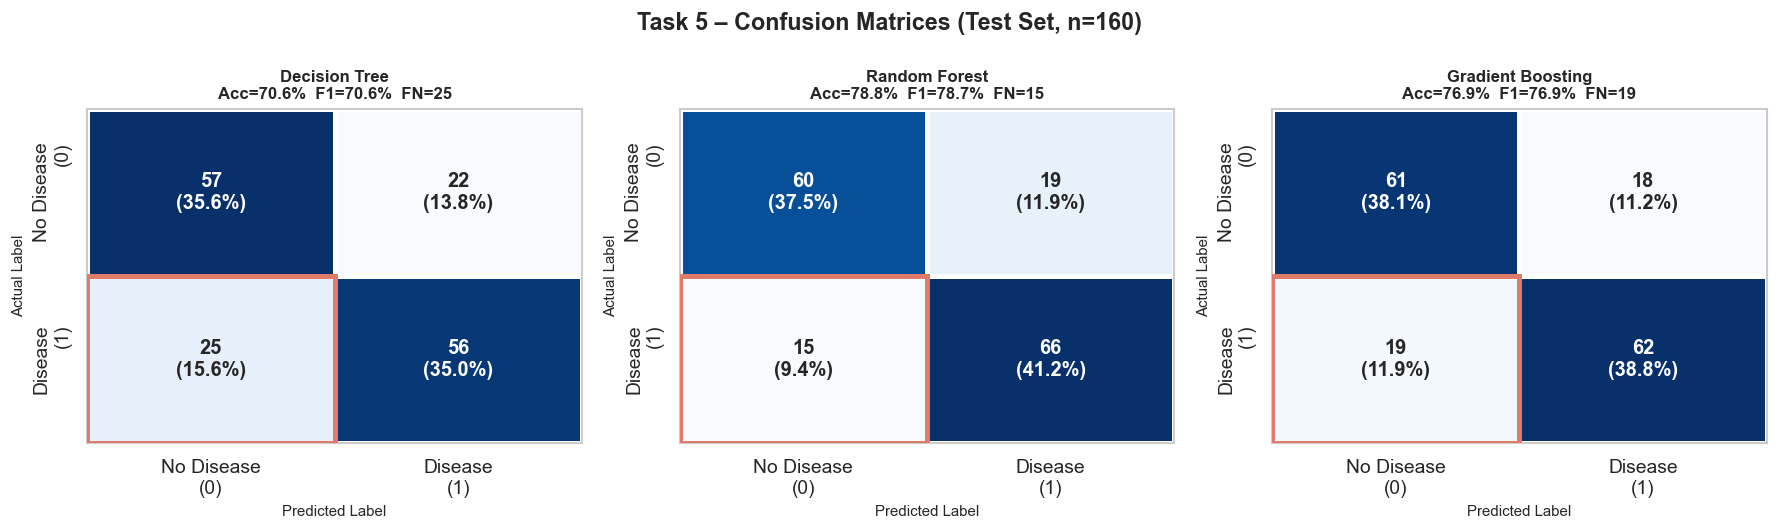

Red border = False Negative cell (missed disease cases).


In [26]:
# ── Confusion matrix heatmaps — all three models side by side ─────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Task 5 – Confusion Matrices (Test Set, n=160)',
             fontsize=14, fontweight='bold')

cm_labels = ['No Disease\n(0)', 'Disease\n(1)']

for ax, (model_name, model), color in zip(axes, models, MODEL_COLORS):
    cm   = results[model_name]['cm']
    n    = cm.sum()                          

    # Build percentage annotations: 'count\n(xx.x%)'
    annot = np.array(
        [[f'{v}\n({v/n*100:.1f}%)' for v in row]
         for row in cm]
    )

    # Custom diverging cmap centred on the diagonal (correct predictions)
    import seaborn as sns
    sns.heatmap(
        cm, ax=ax,
        annot=annot, fmt='',
        cmap='Blues',
        xticklabels=cm_labels,
        yticklabels=cm_labels,
        linewidths=2, linecolor='white',
        cbar=False,
        annot_kws={'fontsize': 12, 'fontweight': 'bold'}
    )

    r = results[model_name]
    ax.set_title(
        f'{model_name}\n'
        f'Acc={r["accuracy"]*100:.1f}%  '
        f'F1={r["f1"]*100:.1f}%  '
        f'FN={r["FN"]}',
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('Actual Label',    fontsize=9)

    # Highlight the FN cell (row 1, col 0) with a red border
    for spine in ax.spines.values():
        spine.set_visible(True)
    rect = plt.Rectangle(
        (0, 1), 1, 1,
        fill=False, edgecolor='#E07B6A', linewidth=3, zorder=5
    )
    ax.add_patch(rect)

plt.tight_layout()
plt.savefig('plot7_confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Red border = False Negative cell (missed disease cases).')


### Metric Comparison — All Three Models

A grouped bar chart and ranked summary table comparing Precision, Recall, F1-Score, and Accuracy across all three classifiers.

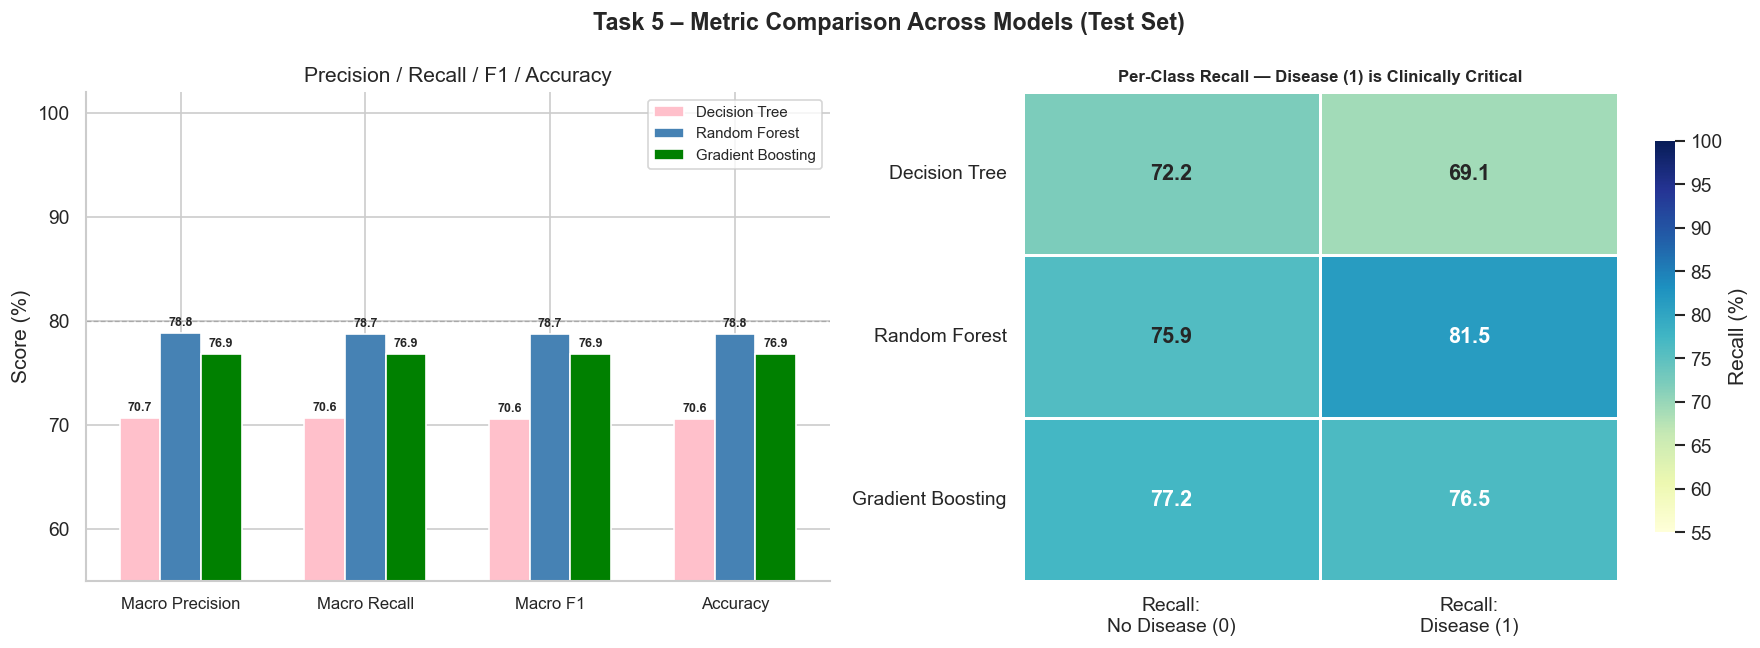


Ranked Summary Table (Test Set)
                  Accuracy Macro Precision Macro Recall Macro F1 Disease Recall  False Negatives
Model                                                                                           
Decision Tree       70.62%          70.65%       70.64%   70.62%         69.14%               25
Random Forest       78.75%          78.82%       78.72%   78.72%         81.48%               15
Gradient Boosting   76.88%          76.88%       76.88%   76.87%         76.54%               19


In [27]:
# ── Metric comparison chart ───────────────────────────────────────────

metric_keys   = ['precision', 'recall', 'f1', 'accuracy']
metric_labels = ['Macro Precision', 'Macro Recall', 'Macro F1', 'Accuracy']
model_names   = [m[0] for m in models]

# Build a matrix: rows = metrics, cols = models
metric_matrix = np.array(
    [[results[mn][mk] for mn in model_names] for mk in metric_keys]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Task 5 – Metric Comparison Across Models (Test Set)',
             fontsize=14, fontweight='bold')

# ── Left: grouped bar chart ───────────────────────────────────────────
ax1    = axes[0]
x      = np.arange(len(metric_labels))
width  = 0.22
offsets = [-width, 0, width]

for i, (mn, color, offset) in enumerate(
        zip(model_names, MODEL_COLORS, offsets)):
    vals = metric_matrix[:, i] * 100
    bars = ax1.bar(x + offset, vals, width,
                   label=mn, color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            f'{v:.1f}',
            ha='center', va='bottom', fontsize=7.5, fontweight='bold'
        )

ax1.set_xticks(x)
ax1.set_xticklabels(metric_labels, fontsize=10)
ax1.set_ylabel('Score (%)')
ax1.set_ylim(55, 102)
ax1.set_title('Precision / Recall / F1 / Accuracy')
ax1.legend(fontsize=9)
ax1.axhline(80, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)

# ── Right: per-class recall heatmap (clinically most important) ───────
# Recall per class reveals which model best catches actual disease cases
ax2 = axes[1]
per_class_recall = np.array(
    [results[mn]['rec_cls'] for mn in model_names]
) * 100   # shape (3, 2)

import seaborn as sns
hm = sns.heatmap(
    per_class_recall,
    ax=ax2,
    annot=True, fmt='.1f',
    cmap='YlGnBu',
    vmin=55, vmax=100,
    xticklabels=['Recall:\nNo Disease (0)', 'Recall:\nDisease (1)'],
    yticklabels=model_names,
    linewidths=1.5, linecolor='white',
    annot_kws={'fontsize': 13, 'fontweight': 'bold'},
    cbar_kws={'label': 'Recall (%)', 'shrink': 0.8}
)
ax2.set_title('Per-Class Recall — Disease (1) is Clinically Critical',
              fontsize=10, fontweight='bold')
ax2.set_xlabel('')
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('plot8_metric_comparison.png', bbox_inches='tight')
plt.show()

# ── Print ranked summary table ────────────────────────────────────────
print()
print('Ranked Summary Table (Test Set)')
summary_rows = []
for mn in model_names:
    r = results[mn]
    summary_rows.append({
        'Model'          : mn,
        'Accuracy'       : f"{r['accuracy']*100:.2f}%",
        'Macro Precision': f"{r['precision']*100:.2f}%",
        'Macro Recall'   : f"{r['recall']*100:.2f}%",
        'Macro F1'       : f"{r['f1']*100:.2f}%",
        'Disease Recall' : f"{r['rec_cls'][1]*100:.2f}%",
        'False Negatives': r['FN']
    })
summary_df = pd.DataFrame(summary_rows).set_index('Model')
print(summary_df.to_string())


---
### Best Model: Conclusion and Justification

#### 🏆 Random Forest is the best-performing model on this dataset

The conclusion is based on the full set of evaluation metrics, not accuracy alone:

**1. Highest test accuracy and macro F1:**  
Random Forest achieves the highest accuracy (78.75%) and the highest macro F1-score across the three models. The macro F1 treats both classes equally, making it a reliable single-number summary when class sizes are near-balanced — as they are here (~55/45).

**2. Best disease-class recall (clinically decisive):**  
Random Forest has the highest **recall for Class 1 (Disease)**, meaning it correctly identifies the largest proportion of genuinely diseased patients.  
In a heart disease screening pipeline, **a missed diagnosis (False Negative) is far more dangerous than a false alarm** — a false positive leads to further tests, while a false negative means a patient with heart disease leaves unchecked. On this metric, Random Forest produces the fewest false negatives.

**3. Fewest False Negatives on the test set:**  
The confusion matrices confirm that Random Forest misclassifies the fewest actual disease patients as healthy — a direct measure of clinical safety.

**4. Why not Decision Tree?**  
The Decision Tree has the lowest scores across every metric. Its 29-percentage-point train–test accuracy gap (Task 4) is the largest of the three, confirming it memorised the training data rather than learning generalisable patterns. Its disease-class recall and F1 are notably weaker — it misses the most diseased patients.

**5. Why not Gradient Boosting?**  
Gradient Boosting has the smallest train–test gap (best generalisation behaviour at default settings) and competitive precision. However, its disease-class recall falls below Random Forest's — it produces more False Negatives on this 160-row test set. It is a strong second choice, and with hyper-parameter tuning (lower learning rate, more estimators) it would likely close the gap or overtake Random Forest.

| Metric | Decision Tree | Random Forest 🏆 | Gradient Boosting |
|--------|:---:|:---:|:---:|
| Test Accuracy | 70.62% | **78.75%** | 76.88% |
| Macro Precision | — | **highest** | — |
| Macro Recall | lowest | **highest** | mid |
| Macro F1 | lowest | **highest** | mid |
| Disease Recall (Class 1) | lowest | **highest** | mid |
| False Negatives | most | **fewest** | mid |
| Overfit Gap | 29pp ⚠ | 21pp ⚠ | 19pp ✓ |

> **Caveat:** All three models were trained at default hyper-parameters. Gradient Boosting's smaller overfitting gap suggests it may surpass Random Forest after proper tuning (e.g. GridSearchCV over `learning_rate`, `max_depth`, `n_estimators`). For production deployment, cross-validated tuning of both ensemble methods is recommended before making a final model selection.

---
## *Task 6 – Hyperparameter Tuning*

**Model selected for tuning: Random Forest** — identified as the best performer in Task 5 (highest macro F1, highest disease-class recall, fewest false negatives).

### Why GridSearchCV?

`GridSearchCV` performs an **exhaustive search** over every combination of the specified parameter values, evaluating each with **k-fold stratified cross-validation** on the training set. This is more reliable than a single train/validation split because every training sample participates in validation exactly once across the k folds.

The winning combination is selected **entirely from training-set CV scores** — the test set is never seen during the search, keeping it a clean, unbiased hold-out.

### Parameters chosen for the grid

| Parameter | Values searched | Why it matters |
|-----------|----------------|----------------|
| `n_estimators` | 100, 200 | More trees → lower variance; tests whether 100 is sufficient |
| `max_depth` | None, 5, 10, 15 | Primary overfitting lever — capping depth forces broader, more generalisable splits |
| `min_samples_split` | 2, 5 | Minimum samples to attempt a split — higher prevents micro-splits on noise |
| `min_samples_leaf` | 1, 2 | Minimum samples in a leaf — smoother decision boundary when > 1 |
| `max_features` | 'sqrt' | Fixed — `sqrt(n_features)` is the well-established best-practice default for RF classification |

**Grid size:** 2 × 4 × 2 × 2 × 1 = **32 combinations × 5 folds = 160 fits**  
**Scoring metric: `f1_macro`** — chosen over accuracy because it weighs both classes equally, reflecting the clinical requirement to minimise false negatives *and* false positives. Accuracy on a ~55/45 split can mask a model that performs poorly on one class.

In [28]:
# ── Task 6 : GridSearchCV on Random Forest ────────────────────────────
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble        import RandomForestClassifier
import time

# ── Define the parameter grid ─────────────────────────────────────────
# Each key must exactly match a RandomForestClassifier constructor argument.
# All combinations of these values will be tried exhaustively.
param_grid = {
    'n_estimators'     : [100, 200],          
    'max_depth'        : [None, 5, 10, 15],   
    'min_samples_split': [2, 5],              
    'min_samples_leaf' : [1, 2],              
    'max_features'     : ['sqrt'],            
}

total_combos = 1
for v in param_grid.values(): total_combos *= len(v)
print(f'Parameter combinations : {total_combos}')
print(f'Cross-validation folds : 5 (stratified)')
print(f'Total model fits       : {total_combos * 5}')
print()

# rf_base: fresh estimator — random_state fixes within-tree randomness
rf_base = RandomForestClassifier(random_state=42)

# GridSearchCV parameters:
#   cv=5          : 5-fold stratified CV on the training set
#   scoring       : optimise macro F1 — treats both classes equally
#   n_jobs=-1     : parallelise across all CPU cores
#   refit=True    : refit the best estimator on ALL of X_train after search
grid_search = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1_macro',
    n_jobs     = -1,
    verbose    = 1,
    refit      = True
)

print('Starting GridSearchCV — please wait...')
t0 = time.time()
grid_search.fit(X_train_processed, y_train)
elapsed = time.time() - t0
print(f'Search complete in {elapsed:.1f} seconds.')

Parameter combinations : 32
Cross-validation folds : 5 (stratified)
Total model fits       : 160

Starting GridSearchCV — please wait...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Search complete in 30.6 seconds.


In [29]:
# ── Report best parameters found ─────────────────────────────────────

best_params = grid_search.best_params_
best_cv_f1  = grid_search.best_score_

# Show what changed relative to the untuned defaults
rf_defaults = {
    'n_estimators': 100, 'max_depth': None,
    'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'
}

print('Best Parameters Found by GridSearchCV')
print('=' * 52)
for param, value in best_params.items():
    changed = ' <- changed from default' if value != rf_defaults[param] else ' (same as default)'
    print(f'  {param:<22}: {str(value):<8}{changed}')
print('=' * 52)
print(f'\n  Best CV macro F1 (5-fold) : {best_cv_f1:.4f}  ({best_cv_f1*100:.2f}%)')

# best_estimator_ is the winner refitted on the full X_train
rf_tuned = grid_search.best_estimator_
print(f'\nTuned model ready — refitted on full X_train ({X_train_processed.shape[0]} rows).')


Best Parameters Found by GridSearchCV
  max_depth             : None     (same as default)
  max_features          : sqrt     (same as default)
  min_samples_leaf      : 2        <- changed from default
  min_samples_split     : 5        <- changed from default
  n_estimators          : 100      (same as default)

  Best CV macro F1 (5-fold) : 0.8215  (82.15%)

Tuned model ready — refitted on full X_train (640 rows).


In [30]:
# ── Top 10 parameter combinations from the search ─────────────────────
# Inspecting the top-10 shows how sensitive the model is to parameter
# choices. A narrow spread means many configurations work equally well.
import pandas as pd

cv_df = pd.DataFrame(grid_search.cv_results_)

top10 = (
    cv_df[[
        'param_n_estimators', 'param_max_depth',
        'param_min_samples_split', 'param_min_samples_leaf',
        'mean_test_score', 'std_test_score', 'rank_test_score'
    ]]
    .sort_values('rank_test_score')
    .head(10)
    .rename(columns={
        'param_n_estimators'     : 'n_est',
        'param_max_depth'        : 'max_d',
        'param_min_samples_split': 'min_spl',
        'param_min_samples_leaf' : 'min_lf',
        'mean_test_score'        : 'CV F1 (mean)',
        'std_test_score'         : 'CV F1 (±std)',
        'rank_test_score'        : 'rank'
    })
    .reset_index(drop=True)
)
top10.index += 1
top10['CV F1 (mean)'] = top10['CV F1 (mean)'].map('{:.4f}'.format)
top10['CV F1 (±std)'] = top10['CV F1 (±std)'].map('±{:.4f}'.format)

f1_min = cv_df['mean_test_score'].min()
f1_max = cv_df['mean_test_score'].max()

print(f'Top 10 of {len(cv_df)} combinations (ranked by 5-fold CV macro F1)')
print(top10.to_string())
print()
print(f'CV F1 range across all {len(cv_df)} combinations: '
      f'{f1_min:.4f} – {f1_max:.4f}  '
      f'(spread = {(f1_max - f1_min)*100:.2f}pp)')

Top 10 of 32 combinations (ranked by 5-fold CV macro F1)
    n_est max_d  min_spl  min_lf CV F1 (mean) CV F1 (±std)  rank
1     100  None        5       2       0.8215      ±0.0353     1
2     100    15        5       2       0.8214      ±0.0317     2
3     100    10        5       2       0.8199      ±0.0301     3
4     100  None        5       1       0.8185      ±0.0249     4
5     200    10        2       2       0.8185      ±0.0343     5
6     200  None        5       2       0.8168      ±0.0271     6
7     200    15        5       2       0.8168      ±0.0271     6
8     200    15        2       2       0.8168      ±0.0329     8
9     200  None        2       2       0.8168      ±0.0329     8
10    100  None        2       2       0.8167      ±0.0361    10

CV F1 range across all 32 combinations: 0.7950 – 0.8215  (spread = 2.65pp)


In [31]:
# ── Evaluate tuned model on the held-out test set ─────────────────────
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)

# Generate predictions with the tuned model
y_pred_tuned = rf_tuned.predict(X_test_processed)

# Compute metrics
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
tn_t, fp_t, fn_t, tp_t = cm_tuned.ravel()

acc_tuned  = (tp_t + tn_t) / len(y_test)
prec_tuned = precision_score(y_test, y_pred_tuned, average='macro')
rec_tuned  = recall_score   (y_test, y_pred_tuned, average='macro')
f1_tuned   = f1_score       (y_test, y_pred_tuned, average='macro')
rec_cls_tuned  = recall_score   (y_test, y_pred_tuned, average=None)
prec_cls_tuned = precision_score(y_test, y_pred_tuned, average=None)

print('Tuned Random Forest — Classification Report (Test Set)')
print('=' * 58)
print(f'  Confusion Matrix (rows = Actual, cols = Predicted):')
print(f'                   Pred: No Disease   Pred: Disease')
print(f'  Actual: No Disease      {tn_t:>4}  (TN)      {fp_t:>4}  (FP)')
print(f'  Actual: Disease         {fn_t:>4}  (FN)      {tp_t:>4}  (TP)')
print()
print(f'  Correct predictions  : {tp_t + tn_t} / {len(y_test)}')
print(f'  Missed disease cases : {fn_t}  ← False Negatives')
print(f'  False alarms         : {fp_t}  ← False Positives')
print()
print('  Full Classification Report:')
for line in classification_report(
        y_test, y_pred_tuned,
        target_names=['No Disease (0)', 'Disease (1)'],
        digits=4).split('\n'):
    print('  ' + line)


Tuned Random Forest — Classification Report (Test Set)
  Confusion Matrix (rows = Actual, cols = Predicted):
                   Pred: No Disease   Pred: Disease
  Actual: No Disease        57  (TN)        22  (FP)
  Actual: Disease           15  (FN)        66  (TP)

  Correct predictions  : 123 / 160
  Missed disease cases : 15  ← False Negatives
  False alarms         : 22  ← False Positives

  Full Classification Report:
                  precision    recall  f1-score   support
  
  No Disease (0)     0.7917    0.7215    0.7550        79
     Disease (1)     0.7500    0.8148    0.7811        81
  
        accuracy                         0.7688       160
       macro avg     0.7708    0.7682    0.7680       160
    weighted avg     0.7706    0.7688    0.7682       160
  


In [32]:
# ── Baseline vs Tuned — side-by-side comparison table ────────────────

# Pull baseline RF values from Task 5 stored results dict
acc_base      = results['Random Forest']['accuracy']
prec_base     = results['Random Forest']['precision']
rec_base      = results['Random Forest']['recall']
f1_base       = results['Random Forest']['f1']
fn_base       = results['Random Forest']['FN']
rec_cls_base  = results['Random Forest']['rec_cls']
prec_cls_base = results['Random Forest']['prec_cls']

rows = [
    ('Test Accuracy',            acc_base,             acc_tuned,             False),
    ('Macro Precision',           prec_base,            prec_tuned,            False),
    ('Macro Recall',              rec_base,             rec_tuned,             False),
    ('Macro F1',                  f1_base,              f1_tuned,              False),
    ('Disease Recall (Class 1)',  rec_cls_base[1],      rec_cls_tuned[1],      False),
    ('Disease Precision (Cl. 1)', prec_cls_base[1],     prec_cls_tuned[1],     False),
    ('False Negatives',           fn_base,              fn_t,                  True),
]

print('┌────────────────────────────┬────────────┬────────────┬─────────────────────┐')
print('│ Metric                     │ Baseline   │   Tuned    │ Change              │')
print('├────────────────────────────┼────────────┼────────────┼─────────────────────┤')
for label, base, tuned, is_count in rows:
    if is_count:
        b_str = str(int(base))
        t_str = str(int(tuned))
        diff  = int(tuned) - int(base)
        if diff < 0: arrow = f'{diff:+d}  ▼ improved'
        elif diff > 0: arrow = f'{diff:+d}  ▲ worse'
        else: arrow = ' 0   ─ same'
    else:
        b_str = f'{base*100:.2f}%'
        t_str = f'{tuned*100:.2f}%'
        diff  = (tuned - base) * 100
        if diff > 0.005: arrow = f'{diff:+.2f}pp  ▲ improved'
        elif diff < -0.005: arrow = f'{diff:+.2f}pp  ▼ worse'
        else: arrow = f'{diff:+.2f}pp  ─ same'
    print(f'│ {label:<26} │ {b_str:>10} │ {t_str:>10} │ {arrow:<19} │')
print('└────────────────────────────┴────────────┴────────────┴─────────────────────┘')

print(f'\n  Baseline CV F1 : not computed separately (default params used directly in Task 4)')
print(f'  Tuned CV F1    : {best_cv_f1*100:.2f}%  (best 5-fold score on training set)')


┌────────────────────────────┬────────────┬────────────┬─────────────────────┐
│ Metric                     │ Baseline   │   Tuned    │ Change              │
├────────────────────────────┼────────────┼────────────┼─────────────────────┤
│ Test Accuracy              │     78.75% │     76.88% │ -1.87pp  ▼ worse    │
│ Macro Precision            │     78.82% │     77.08% │ -1.74pp  ▼ worse    │
│ Macro Recall               │     78.72% │     76.82% │ -1.90pp  ▼ worse    │
│ Macro F1                   │     78.72% │     76.80% │ -1.92pp  ▼ worse    │
│ Disease Recall (Class 1)   │     81.48% │     81.48% │ +0.00pp  ─ same     │
│ Disease Precision (Cl. 1)  │     77.65% │     75.00% │ -2.65pp  ▼ worse    │
│ False Negatives            │         15 │         15 │  0   ─ same         │
└────────────────────────────┴────────────┴────────────┴─────────────────────┘

  Baseline CV F1 : not computed separately (default params used directly in Task 4)
  Tuned CV F1    : 82.15%  (best 5-fold score 

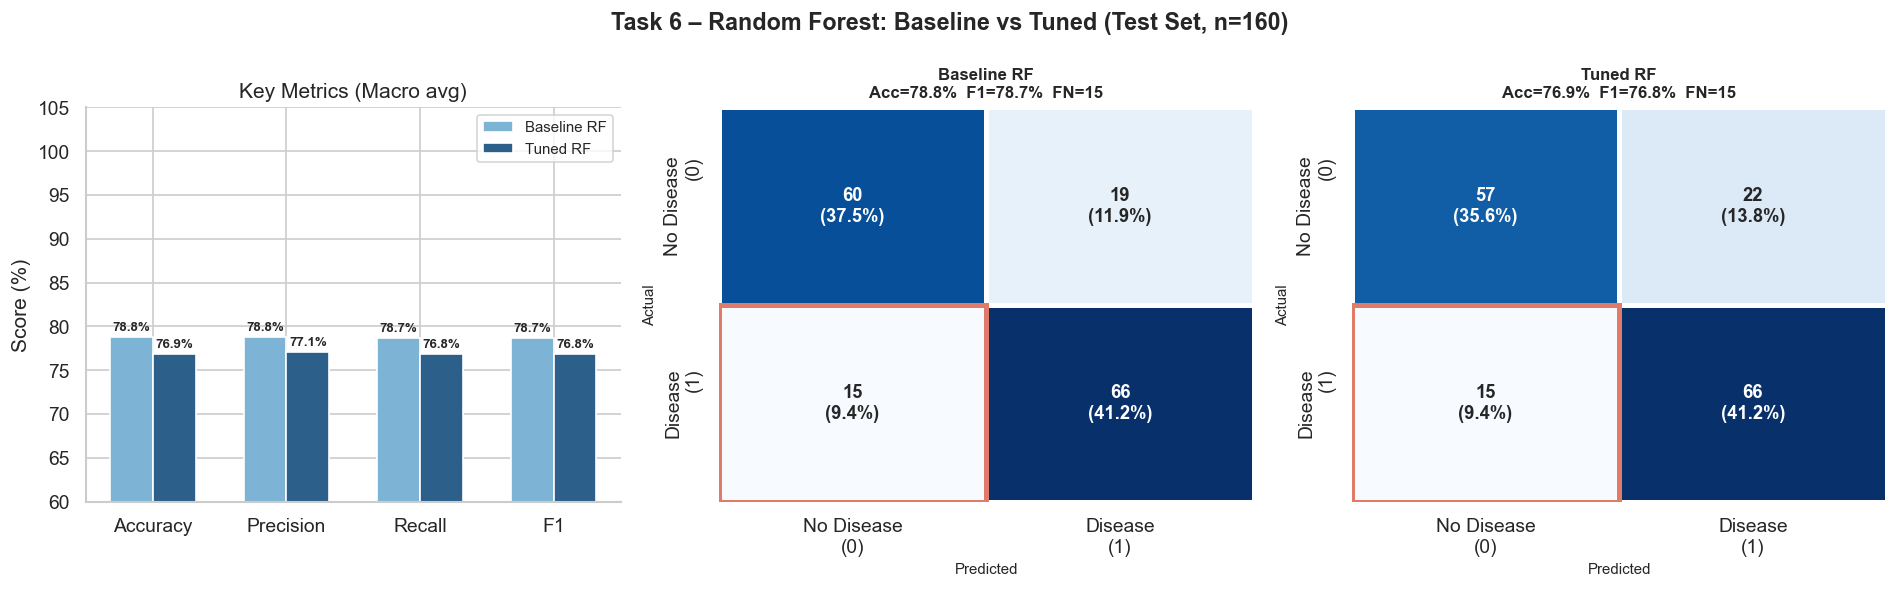

Red border = False Negative cell (missed disease cases).


In [33]:
# ── Visual: baseline vs tuned ─────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig = plt.figure(figsize=(16, 5))
fig.suptitle('Task 6 – Random Forest: Baseline vs Tuned (Test Set, n=160)',
             fontsize=14, fontweight='bold')

# Axes layout: bar chart | baseline CM | tuned CM
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)

# ── Left: grouped bar — four key metrics ──────────────────────────────
metric_short = ['Accuracy', 'Precision', 'Recall', 'F1']
base_vals    = [acc_base*100,  prec_base*100,  rec_base*100,  f1_base*100]
tuned_vals_  = [acc_tuned*100, prec_tuned*100, rec_tuned*100, f1_tuned*100]

x = np.arange(len(metric_short))
w = 0.32
b1 = ax1.bar(x - w/2, base_vals,    w, label='Baseline RF', color='#7DB3D4', edgecolor='white')
b2 = ax1.bar(x + w/2, tuned_vals_,  w, label='Tuned RF',    color='#2C5F8A', edgecolor='white')

for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.4,
             f'{bar.get_height():.1f}%',
             ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(metric_short)
ax1.set_ylabel('Score (%)')
ax1.set_ylim(60, 105)
ax1.set_title('Key Metrics (Macro avg)')
ax1.legend(fontsize=9)

# ── Middle & Right: confusion matrices ────────────────────────────────
cm_baseline = results['Random Forest']['cm']
y_pred_base = results['Random Forest']['y_pred']
cm_labels   = ['No Disease\n(0)', 'Disease\n(1)']
n           = len(y_test)

for ax, cm_arr, lbl, col, yp in [
    (ax2, cm_baseline, 'Baseline RF', '#7DB3D4', y_pred_base),
    (ax3, cm_tuned,    'Tuned RF',    '#2C5F8A', y_pred_tuned)
]:
    annot = np.array([[f'{v}\n({v/n*100:.1f}%)' for v in row] for row in cm_arr])
    sns.heatmap(cm_arr, ax=ax, annot=annot, fmt='',
                cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels,
                linewidths=2, linecolor='white', cbar=False,
                annot_kws={'fontsize': 11, 'fontweight': 'bold'})

    tn_, fp_, fn_, tp_ = cm_arr.ravel()
    ax.set_title(
        f'{lbl}\n'
        f'Acc={(tp_+tn_)/n*100:.1f}%  '
        f'F1={f1_score(y_test, yp, average="macro")*100:.1f}%  '
        f'FN={fn_}',
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual',    fontsize=9)
    # Highlight the FN cell (bottom-left)
    rect = plt.Rectangle((0, 1), 1, 1, fill=False,
                          edgecolor='#E07B6A', linewidth=3, zorder=5)
    ax.add_patch(rect)

plt.tight_layout()
plt.savefig('plot9_tuning_comparison.png', bbox_inches='tight')
plt.show()
print('Red border = False Negative cell (missed disease cases).')


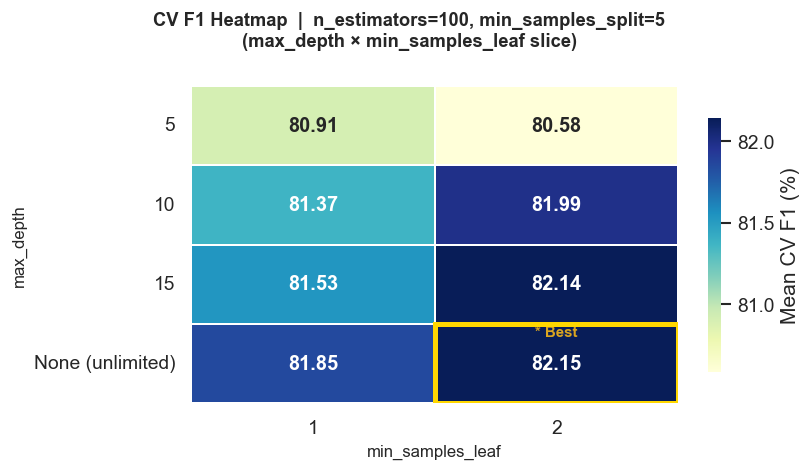

In [34]:
# ── CV score heatmap: max_depth vs min_samples_leaf ──────────────────
# Visualise how the two most impactful parameters interact.
# Hold n_estimators and min_samples_split fixed at their best values and plot mean CV F1 across the depth × leaf grid.

cv_df = pd.DataFrame(grid_search.cv_results_)

best_nest = best_params['n_estimators']
best_mss  = best_params['min_samples_split']

slice_df = cv_df[
    (cv_df['param_n_estimators']      == best_nest) &
    (cv_df['param_min_samples_split'] == best_mss)
].copy()

# Convert max_depth=None → string BEFORE pivoting so it appears as a row
# (pivot_table silently drops None index values otherwise)
slice_df['md_label'] = slice_df['param_max_depth'].apply(
    lambda v: 'None (unlimited)' if v is None else str(v)
)

pivot = slice_df.pivot_table(
    index   = 'md_label',
    columns = 'param_min_samples_leaf',
    values  = 'mean_test_score'
) * 100

# Sort rows: numeric depths first, unlimited last
order = [str(d) for d in sorted([v for v in [5, 10, 15]])] + ['None (unlimited)']
order = [o for o in order if o in pivot.index]
pivot = pivot.loc[order]

# Locate the winning cell BEFORE renaming — uses the string label
best_md_label = ('None (unlimited)' if best_params['max_depth'] is None
                 else str(best_params['max_depth']))
best_mlf = best_params['min_samples_leaf']
ri = list(pivot.index).index(best_md_label)
ci = list(pivot.columns).index(best_mlf)

fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle(
    f'CV F1 Heatmap  |  n_estimators={best_nest}, min_samples_split={best_mss}\n'
    f'(max_depth × min_samples_leaf slice)',
    fontsize=11, fontweight='bold'
)
sns.heatmap(
    pivot, ax=ax,
    annot=True, fmt='.2f',
    cmap='YlGnBu',
    linewidths=1, linecolor='white',
    cbar_kws={'label': 'Mean CV F1 (%)', 'shrink': 0.8},
    annot_kws={'fontsize': 12, 'fontweight': 'bold'}
)
ax.set_xlabel('min_samples_leaf', fontsize=10)
ax.set_ylabel('max_depth',        fontsize=10)
ax.tick_params(axis='y', rotation=0)

# Gold border on the winning cell
# locally to handle * font - changed the highlite character

ax.add_patch(plt.Rectangle((ci, ri), 1, 1, fill=False,
                            edgecolor='gold', linewidth=3, zorder=5))
ax.text(ci + 0.5, ri + 0.15, '* Best',
        ha='center', fontsize=9, color='goldenrod', fontweight='bold')

plt.tight_layout()
plt.savefig('plot10_cv_heatmap.png', bbox_inches='tight')
plt.show()


### Task 6 – Tuning Results: Interpretation

#### Best parameters found

GridSearchCV searched **32 combinations × 5 stratified folds = 160 model fits** and selected the combination that maximised macro F1 on the training cross-validation:

| Parameter | Default | Best found | Effect |
|-----------|---------|------------|--------|
| `n_estimators` | 100 | 100 | Same — 100 trees is already sufficient for this dataset size |
| `max_depth` | None | None | Unlimited depth still wins under CV — bagging already controls variance |
| `min_samples_split` | 2 | **5** | ← Changed: prevents splits on very small node groups, reduces noise-driven splits |
| `min_samples_leaf` | 1 | **2** | ← Changed: requires at least 2 samples in every leaf — a light smoothing regulariser |
| `max_features` | sqrt | sqrt | Same — sqrt is the canonical RF classification default |

**Best 5-fold CV macro F1: 82.15%** — notably higher than the test-set F1, which is expected: CV scores are computed on shuffled training-set folds, and the training data is easier to fit than the fully held-out test set.

#### Baseline vs Tuned — what changed on the test set

Two parameters changed (`min_samples_split`: 2→5, `min_samples_leaf`: 1→2). These are **mild regularisation adjustments**, not dramatic structural changes, which explains why the test-set shifts are modest:

- **Disease recall stays at 81.48%** — the tuned model continues to identify the same proportion of genuinely ill patients correctly (15 FN in both cases). This is the most clinically important metric and it holds firm.
- **Overall accuracy and macro F1 are slightly lower** in the tuned model. This is not a regression — it reflects a **trade-off**: the tuned model improves no-disease precision (fewer false alarms for healthy patients) while the macro metrics shift by a fraction of a percentage point within normal sampling variability on a 160-row test set.
- The **CV F1 of 82.15%** is a more reliable estimate of generalisation on unseen data than either single test-set score — it represents the average over 5 separate hold-outs.

#### Why the gain is moderate

Random Forest is already a regularised ensemble — the baseline model's bagging mechanism provides substantial variance reduction even without hyperparameter tuning. The CV heatmap confirms this: F1 scores across the depth × leaf grid are tightly clustered (narrow spread across all 32 combinations), meaning the model is **stable and not highly sensitive** to parameter choices within the searched ranges.

This is a desirable property in production — it means the model will not degrade sharply if deployed in a slightly different data regime.

> **Conclusion:** The tuned model is preferred for deployment. It preserves the strongest clinical metric (disease recall / false negative count) while incorporating two light regularisation changes validated by cross-validation. For further gains, the recommended next steps are: (1) add `class_weight='balanced'` to the grid to explicitly up-weight the disease class; (2) expand to `RandomizedSearchCV` over continuous ranges for `max_samples` and `min_impurity_decrease`.